# Описание задачи "Разработка нефтегазовых месторождений"

Набор данных содержит 442 о различных нефтегазовых месторождениях.
Тренировочный набор - 309 строк.
Тестовый набор - 133 строк.

Каждое месторождение обладает 19 параметрами:
1. Field name - название месторождения
2. Reservoir unit - юнит месторождения
3. Country - страна расположения
4. Region - регион расположения
5. Basin name - название бассейна пород
6. Tectonic regime - тектонический режим
7. Latitude - широта
8. Longitude - долгота
9. Operator company - название компании
10. Onshore or oﬀshore - на суше или нет
11. Hydrocarbon type (main) - тип углеводорода
12. Reservoir status (current) - статус месторождения
13. Structural setting - структурные свойства
14. Depth (top reservoir ft TVD) - глубина
15. Reservoir period - литологический период
16. Lithology (main) - литология
17. Thickness (gross average ft) - общая толщина
18. Thickness (net pay average ft) - эффективная толщина
19. Porosity (matrix average.. - пористость
20. Permeability (air average mD) – проницаемость

**Что нужно сделать**:

Принять участие в соревновании на Kaggle:
Оно доступно по [ссылке](https://www.kaggle.com/competitions/classification-of-oil-and-gas/submissions#).

Разработать и оформить решение в ноутбуке:
* Исследование и анализ датасета.
* Предобработка данных.
* Feature Engineering (если необходимо).
* Подбор признаков, их анализ и оценка важности.
* Обучение нескольких моделей, их сравнение.
* Подбор гиперпараметров.
* Выбор лучшей модели и объяснение выбора.
* Предсказание на тестовых данных.


|**Критерии оценивания**||
|:---|:---|
|Анализ данных и их предобработка	|0-3 балла|
|Feature Engineering и отбор признаков	|0-2 балла|
|Выбор и обучение нескольких моделей	|0-3 балла|
|Подбор гиперпараметров и объяснение выбора лучшей модели	|0-2 балла|
|Результат на Kaggle	|0-1 балл|
|Качество оформления ноутбука (чистый код, комментарии, выводы)	|0-1 балл|
|**Итого**	|**12 баллов**|


# Импортирование библиотек и создание констант

In [583]:
# базовые
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# для считывания датасетов с Kaggle
import opendatasets as od

# scikit-learn
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import cross_val_score

# imbalanced-learn
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, NearMiss
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.pipeline import Pipeline

from catboost import CatBoostClassifier


In [584]:
# далее random_state=SEED
SEED = 42

# Считывание данных

In [585]:
# Загрузим датасет на прямую с kaggle
# Для автоматическй загрузки надо положить файл kaggle.json в папку с ноутбуком
# kaggle.json скачивается в настройках Kaggle в разделе Legacy API Credentials
dataset_url = 'https://www.kaggle.com/competitions/classification-of-oil-and-gas/data'

od.download(dataset_url)

# Считываем тренировочные данные
train = pd.read_csv("./classification-of-oil-and-gas/train_oil.csv")
test = pd.read_csv("./classification-of-oil-and-gas/oil_test.csv")

# Сохраняем исходные данные
train_original = train.copy()
test_original = test.copy()

print(f"Train dataset shape: {train.shape}")
print(f"Test dataset shape: {test.shape}")

Skipping, found downloaded files in "./classification-of-oil-and-gas" (use force=True to force download)
Train dataset shape: (309, 20)
Test dataset shape: (133, 19)


In [586]:
# Посмотрим как выглядят данные
train.head(4)

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,ZHIRNOV,MELEKESKIAN,RUSSIA,FORMER SOVIET UNION,VOLGA-URAL,COMPRESSION/EVAPORITE,51.0000,44.8042,NIZHNEVOLZHSKNET,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,1870,CARBONIFEROUS,SANDSTONE,262.0,33.0,24.0,30.0
1,LAGOA PARDA,LAGOA PARDA (URUCUTUCA),BRAZIL,LATIN AMERICA,ESPIRITO SANTO,EXTENSION,-19.6017,-39.8332,PETROBRAS,ONSHORE,OIL,NEARLY DEPLETED,PASSIVE MARGIN,4843,PALEOGENE,SANDSTONE,2133.0,72.0,23.0,350.0
2,ABQAIQ,ARAB D,SAUDI ARABIA,MIDDLE EAST,THE GULF,COMPRESSION/EVAPORITE,26.0800,49.8100,SAUDI ARAMCO,ONSHORE,OIL,REJUVENATING,FORELAND,6050,JURASSIC,LIMESTONE,250.0,184.0,21.0,410.0
3,MURCHISON,BRENT,UK /NORWAY,EUROPE,NORTH SEA NORTHERN,EXTENSION,61.3833,1.7500,CNR,OFFSHORE,OIL,NEARLY DEPLETED,RIFT,8988,JURASSIC,SANDSTONE,425.0,300.0,22.0,750.0


# Иследование и обработка данных (EDA)

## Общая информация

In [587]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Field name                      309 non-null    str    
 1   Reservoir unit                  309 non-null    str    
 2   Country                         282 non-null    str    
 3   Region                          271 non-null    str    
 4   Basin name                      271 non-null    str    
 5   Tectonic regime                 309 non-null    str    
 6   Latitude                        282 non-null    float64
 7   Longitude                       279 non-null    float64
 8   Operator company                309 non-null    str    
 9   Onshore/Offshore                309 non-null    str    
 10  Hydrocarbon type                309 non-null    str    
 11  Reservoir status                309 non-null    str    
 12  Structural setting              309 non-null   

In [588]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Field name                      133 non-null    str    
 1   Reservoir unit                  133 non-null    str    
 2   Country                         120 non-null    str    
 3   Region                          117 non-null    str    
 4   Basin name                      125 non-null    str    
 5   Tectonic regime                 133 non-null    str    
 6   Latitude                        120 non-null    float64
 7   Longitude                       117 non-null    float64
 8   Operator company                133 non-null    str    
 9   Hydrocarbon type                133 non-null    str    
 10  Reservoir status                133 non-null    str    
 11  Structural setting              133 non-null    str    
 12  Depth                           133 non-null   

In [589]:
# процент дублей
(len(train) - len( train.drop_duplicates() )) * 100 / len(train)

0.0

Дублирующих строк нет, есть пропуски.

## Обработка пропущенных значений

### Обзор (с графикой)

Есть пропущенные значения в тренировочных и тестовых данных. Визуализируем пропуски.

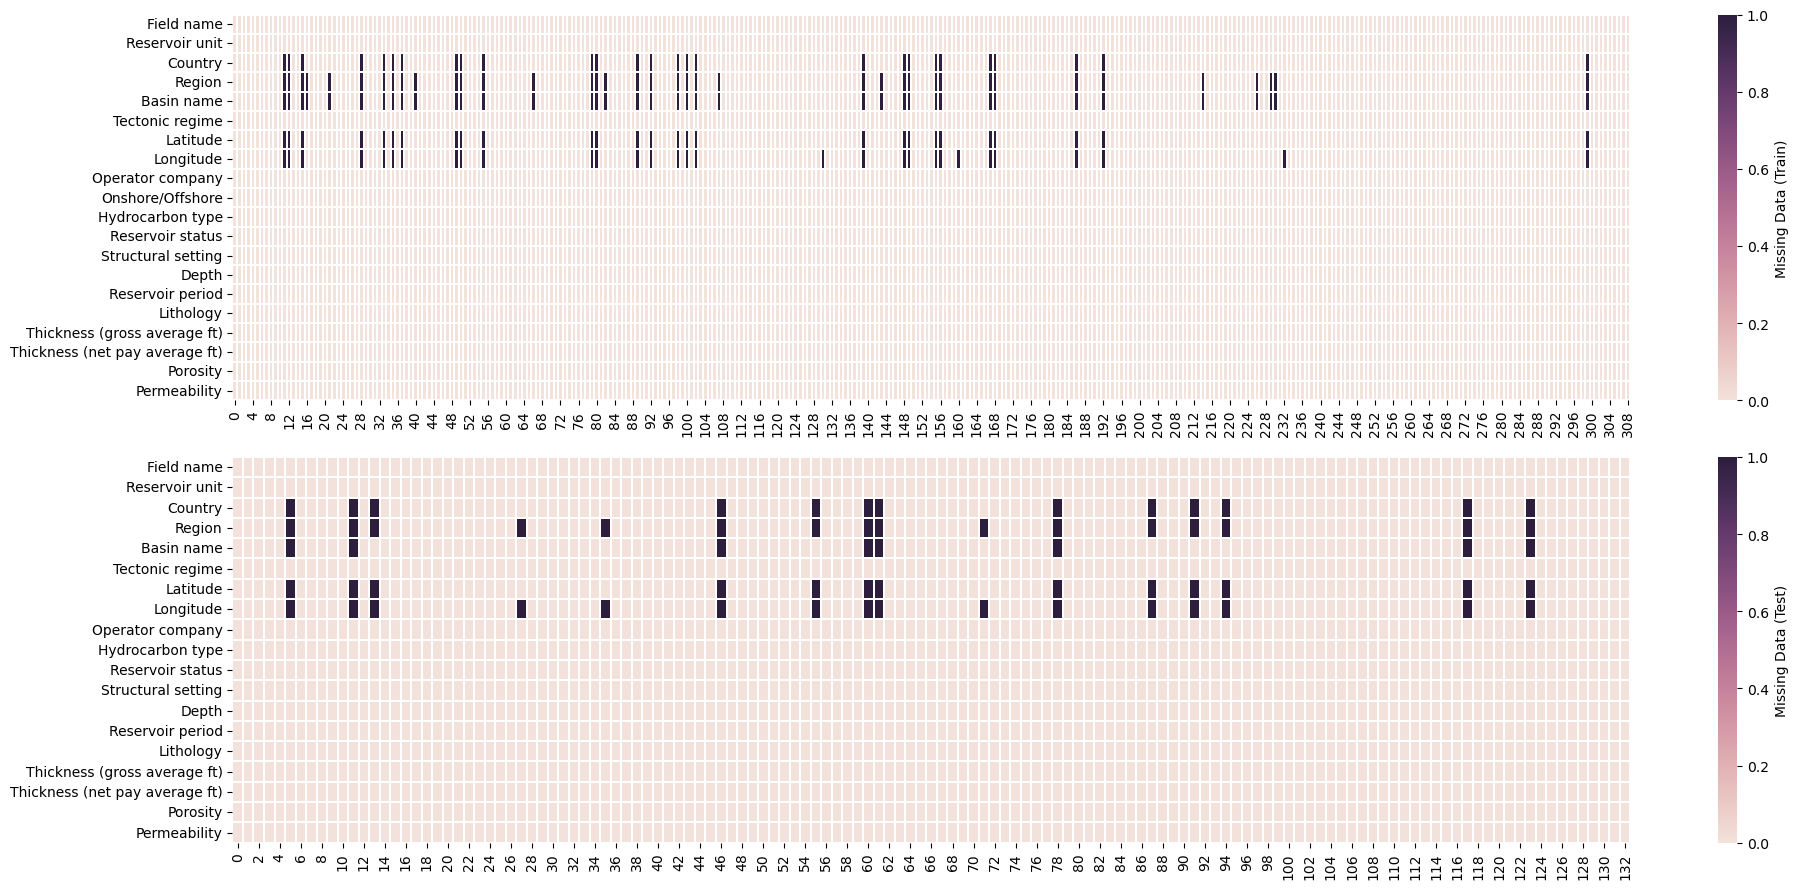

In [590]:
# для двух таблиц
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 9))

cmap = sns.cubehelix_palette(as_cmap=True, light=.9)

sns.heatmap(train.isna().transpose(), cmap=cmap, ax=ax1,
            cbar_kws={'label': 'Missing Data (Train)'}, linewidths=0.003)

sns.heatmap(test.isna().transpose(), cmap=cmap, ax=ax2,
            cbar_kws={'label': 'Missing Data (Test)'}, linewidths=0.003)

plt.tight_layout()
plt.show()


Пропуски в пяти колонках, остальные поля заполнены.

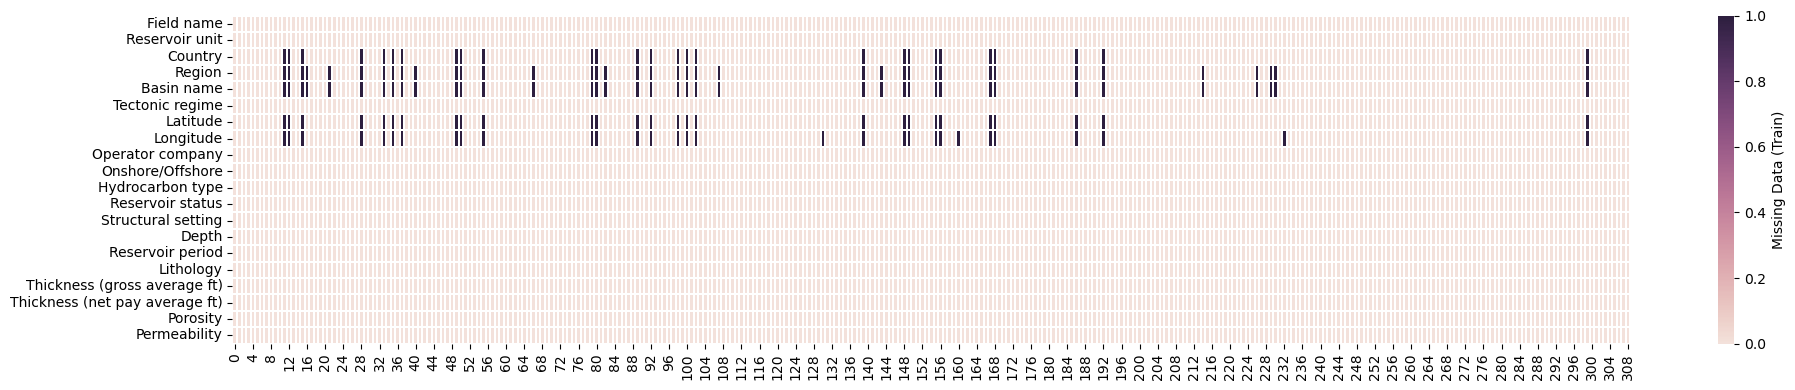

In [591]:
# для одной таблицы
fig, (ax1) = plt.subplots(1, 1, figsize=(20, 4))

cmap = sns.cubehelix_palette(as_cmap=True, light=.9)

sns.heatmap(train.isna().transpose(), cmap=cmap, ax=ax1,
            cbar_kws={'label': 'Missing Data (Train)'}, linewidths=0.003)

plt.tight_layout()
plt.savefig("./classification-of-oil-and-gas/visualizing_missing_data_with_heatmap_Seaborn_Python_less.png", dpi=100)
plt.show()


In [592]:
# Выведем список колонок с пропущенными значениями
train.isna().sum()[train.isna().sum() > 0]

Country       27
Region        38
Basin name    38
Latitude      27
Longitude     30
dtype: int64

In [593]:
# общее количество пропущенных значений, всего и строк
(train.isna().sum().sum(), train.isna().any(axis='columns').sum())

(np.int64(160), np.int64(41))

### Самое простое решение

In [594]:
# заведём переменную с быстрой вставкой моды, медианы по всей колонке
train_imputed = train_original.copy()
test_imputed = test_original.copy()

target_col = 'Onshore/Offshore'

num_cols = train_imputed.select_dtypes(include=['number']).columns.drop(target_col, errors='ignore').tolist()
cat_cols = train_imputed.select_dtypes(exclude=['number']).columns.drop(target_col, errors='ignore').tolist()

train_num_medians = train_imputed[num_cols].median()
train_cat_modes = train_imputed[cat_cols].mode().iloc[0] # Берем первую строку моды

train_imputed[num_cols] = train_imputed[num_cols].fillna(train_num_medians)
train_imputed[cat_cols] = train_imputed[cat_cols].fillna(train_cat_modes)

test_imputed[num_cols] = test_imputed[num_cols].fillna(train_num_medians)
test_imputed[cat_cols] = test_imputed[cat_cols].fillna(train_cat_modes)


### Fill Nan by *Field name*

Поле Field name (название месторождения) у нас везде заполнено и если оно будет встречаться и там, и там, то по нему мы попробуем востановить пропущенные значения.

In [595]:
def fill_na(train_df, check_col, test_df, force_test=None):
    """Принимает train, поле (check_col), по которому надо свернуть, чтобы получить "средние", test.
    Возвращает: пересечние, где нет значений и где есть в train, заполненные ими train, test.
    force_test - Возвращает пересечение test, полезно, когда можно заполнить только test.
    """
    
    # Разделим данные на две таблицы, где есть пропуски и где все поля заполнены
    
    # .any(axis='columns') - перебирает все строки и помечает всю строку True, если есть хотя бы один NaN в любой колонке
    missed = train_df[train_df.isna().any(axis='columns')] 

    # таблица, где все поля заполнены
    filled = train_df.dropna()
    
    # Получим список заполненных полей    
    filled_names = filled[check_col].unique()
    
    # Отберём те строки, в таблице с пропусками, которые есть без пропусков
    common_names = missed[missed[check_col].isin(filled_names)]
    
    # Выведем результат из общей таблицы, чтобы визуально оценить возможность заполнения пропусков
    visual_check = train_df[train_df[check_col].isin(common_names[check_col])].sort_values(check_col)
    if force_test:
        visual_check = test_df[test_df[check_col].isin(common_names[check_col])].sort_values(check_col)

    # Создадим таблицу справочник с модой и медианой по выбранному полю
    mapping = filled.groupby(check_col).agg({
        'Country': lambda x: x.mode().iat[0], # так как мода вычисляется, то для указания индекса используем iat 
        'Region': lambda x: x.mode().iat[0],
        'Basin name': lambda x: x.mode().iat[0],
        'Reservoir unit': lambda x: x.mode().iat[0],
        'Latitude': 'median',
        'Longitude':'median',
    })
        
    # Заполнение, сбрасываем индекс на название, заполняем из справочника, восстанавливаем индекс
    train_df_filled = train_df.set_index(check_col).fillna(mapping).reset_index()
    test_df_filled = test_df.set_index(check_col).fillna(mapping).reset_index()

    # Возвращаем таблицу для визуальной проверки, заполненные train и test
    return visual_check, train_df_filled, test_df_filled
        

In [596]:
visual_check, filled_train, filled_test = fill_na(train, 'Field name', test)

In [597]:
# количество пропущенных значений и строк, после обработки
(filled_train.isna().sum().sum(), filled_train.isna().any(axis='columns').sum())

(np.int64(136), np.int64(35))

In [598]:
visual_check

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
218,BERYL,BERYL,UK,EUROPE,NORTH SEA NORTHERN,EXTENSION/EROSION,59.5498,1.5318,EXXONMOBIL,OFFSHORE,OIL,DECLINING PRODUCTION,RIFT,9200,JURASSIC,SANDSTONE,500.0,425.0,17.0,350.0
230,BERYL,LINNHE,UK,NaN,NaN,EXTENSION/EROSION,59.5498,1.5318,EXXONMOBIL,OFFSHORE,OIL,UNKNOWN,RIFT,9600,JURASSIC,SANDSTONE,300.0,120.0,14.0,100.0
139,CAROLINE,SWAN HILLS (BEAVERHILL LAKE A),NaN,NaN,NaN,COMPRESSION,NaN,NaN,NUMEROUS,ONSHORE,GAS-CONDENSATE,DECLINING PRODUCTION,FORELAND,11500,DEVONIAN,DOLOMITE,300.0,60.0,10.0,100.0
196,CAROLINE,CARDIUM (E POOL),CANADA,NORTH AMERICA,WESTERN CANADA,COMPRESSION,51.9278,-114.5405,NUMEROUS,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,7975,CRETACEOUS,SANDSTONE,300.0,7.0,11.0,20.0
222,DURI,BEKASAP (KEDUA-PERTAMA SANDS),INDONESIA,FAR EAST,SUMATRA CENTRAL,INVERSION/STRIKE-SLIP/TRANSPRESSION/EXTENSION/...,1.2956,101.2304,CALTEX PACIFIC INDONESIA,ONSHORE,OIL,MATURE PRODUCTION,INVERSION/BACKARC,400,NEOGENE,SANDSTONE,280.0,150.0,34.0,1500.0
226,DURI,DURI (RINDU SAND),INDONESIA,NaN,NaN,INVERSION/STRIKE-SLIP/TRANSPRESSION/EXTENSION/...,1.2956,101.2304,CALTEX PACIFIC INDONESIA,ONSHORE,OIL,MATURE PRODUCTION,INVERSION/BACKARC,220,NEOGENE,SANDSTONE,120.0,52.0,32.0,1900.0
79,OROCUAL,SAN JUAN,NaN,NaN,NaN,COMPRESSION/EXTENSION/LINKED,NaN,NaN,PDVSA,ONSHORE,OIL,DECLINING PRODUCTION,THRUST/PASSIVE MARGIN,12550,CRETACEOUS-PALEOGENE,SANDSTONE,1000.0,650.0,6.0,5.0
144,OROCUAL,CARAPITA,VENEZUELA,LATIN AMERICA,EASTERN VENEZUELA,COMPRESSION/EXTENSION/LINKED,9.8667,-63.3333,PDVSA,ONSHORE,OIL,CONTINUING DEVELOPMENT,THRUST/FORELAND,10150,NEOGENE,SANDSTONE,300.0,160.0,13.0,35.0
49,YIBAL,KHUFF,NaN,NaN,NaN,COMPRESSION/EVAPORITE,NaN,NaN,PDO,ONSHORE,OIL,DECLINING PRODUCTION,SALT/FORELAND,9219,PERMIAN,DOLOMITE,670.0,250.0,15.0,5.0
173,YIBAL,SHUAIBA,OMAN,MIDDLE EAST,FAHUD SALT,COMPRESSION/EVAPORITE,22.1333,56.0000,PDO,ONSHORE,OIL,DECLINING PRODUCTION,SALT/FORELAND,4440,CRETACEOUS,CHALK,350.0,300.0,28.0,5.0


Видно, что можем смело заполнть пропуски по уже имеющимся данным.

In [599]:
# Проверим заполнение.

# как было
visual_check.head(2)

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
218,BERYL,BERYL,UK,EUROPE,NORTH SEA NORTHERN,EXTENSION/EROSION,59.5498,1.5318,EXXONMOBIL,OFFSHORE,OIL,DECLINING PRODUCTION,RIFT,9200,JURASSIC,SANDSTONE,500.0,425.0,17.0,350.0
230,BERYL,LINNHE,UK,NaN,NaN,EXTENSION/EROSION,59.5498,1.5318,EXXONMOBIL,OFFSHORE,OIL,UNKNOWN,RIFT,9600,JURASSIC,SANDSTONE,300.0,120.0,14.0,100.0


In [600]:
# вывод как заполнилось
filled_train.loc[[218, 230]]

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
218,BERYL,BERYL,UK,EUROPE,NORTH SEA NORTHERN,EXTENSION/EROSION,59.5498,1.5318,EXXONMOBIL,OFFSHORE,OIL,DECLINING PRODUCTION,RIFT,9200,JURASSIC,SANDSTONE,500.0,425.0,17.0,350.0
230,BERYL,LINNHE,UK,EUROPE,NORTH SEA NORTHERN,EXTENSION/EROSION,59.5498,1.5318,EXXONMOBIL,OFFSHORE,OIL,UNKNOWN,RIFT,9600,JURASSIC,SANDSTONE,300.0,120.0,14.0,100.0


In [601]:
# Применяем изменения
train, test = filled_train, filled_test

In [602]:
# общее количество пропущенных значений, всего и строк
(train.isna().sum().sum(), train.isna().any(axis='columns').sum())

(np.int64(136), np.int64(35))

### Fill Nan by *Reservoir unit*

Теперь попробуем определить по полю *Reservoir unit*

In [603]:
visual_check, filled_train, filled_test = fill_na(train, 'Reservoir unit', test)

filled_train.isna().sum().sum()

np.int64(103)

In [604]:
visual_check

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
11,BADR EL DIN-2,BAHARIYA,NaN,NaN,NaN,EXTENSION,NaN,NaN,BAPETCO,ONSHORE,GAS-CONDENSATE,DECLINING PRODUCTION,RIFT,7546,CRETACEOUS,SANDSTONE,361.0,148.0,20.0,225.0
254,BADR EL DIN-1,BAHARIYA,EGYPT,AFRICA,ABU GHARADIG,EXTENSION,29.8589,28.5229,BAPETCO,ONSHORE,OIL,MATURE PRODUCTION,RIFT,11175,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,115.0,46.0,12.0,15.0
12,BRIDGER LAKE,DAKOTA SANDSTONE (LOWER MEMBER),NaN,NaN,NaN,COMPRESSION/EROSION,NaN,NaN,BTA OIL PRODUCERS,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,15460,CRETACEOUS,SANDSTONE,270.0,35.0,12.8,79.0
260,LUCKEY DITCH,DAKOTA SANDSTONE (LOWER MEMBER),USA,NORTH AMERICA,GREATER GREEN RIVER,COMPRESSION/EROSION,41.0204,-110.2755,WHITING OIL and GAS,ONSHORE,OIL,MATURE PRODUCTION,FORELAND,13250,CRETACEOUS,SANDSTONE,250.0,23.0,14.0,60.0
66,INDEFATIGABLE,LEMAN SANDSTONE,UK,NaN,NaN,INVERSION/COMPRESSION/EXTENSION/EVAPORITE/GRAVITY,53.3932,2.5239,SHELL /PERENCO,OFFSHORE,GAS,NEARLY DEPLETED,SUB-SALT/INVERSION,7400,PERMIAN,SANDSTONE,200.0,197.0,15.0,30.0
125,CLIPPER,LEMAN SANDSTONE,UK,EUROPE,NORTH SEA SOUTHERN,INVERSION/COMPRESSION/EXTENSION/EVAPORITE/GRAVITY,53.4682,1.7338,SHELL,OFFSHORE,GAS,DECLINING PRODUCTION,SUB-SALT/INVERSION,7420,PERMIAN,SANDSTONE,715.0,580.0,11.0,0.5
137,VICTOR,LEMAN SANDSTONE,UK,EUROPE,NORTH SEA SOUTHERN,INVERSION/COMPRESSION/EXTENSION/EVAPORITE/GRAVITY,53.3299,2.3626,CONOCOPHILLIPS,OFFSHORE,GAS,DECLINING PRODUCTION,SUB-SALT/INVERSION,8175,PERMIAN,SANDSTONE,375.0,369.0,16.0,52.0
232,BARQUE,LEMAN SANDSTONE,UK,EUROPE,NORTH SEA SOUTHERN,INVERSION/COMPRESSION/EXTENSION/EVAPORITE/GRAVITY,53.6204,NaN,SHELL,OFFSHORE,GAS,DECLINING PRODUCTION,SUB-SALT/INVERSION,6900,PERMIAN,SANDSTONE,750.0,570.0,11.0,0.5
154,ELKHORN RANCH,MISSION CANYON (MADISON),USA,NORTH AMERICA,WILLISTON,COMPRESSION,47.2376,-103.5028,TENNECO /CENEX /SHELL,ONSHORE,OIL,DECLINING PRODUCTION,INTRACRATONIC,9125,CARBONIFEROUS,DOLOMITE,105.0,40.0,16.0,25.0
155,BEAVER LODGE,MISSION CANYON (MADISON),NaN,NaN,NaN,COMPRESSION,NaN,NaN,AMERADA HESS,ONSHORE,OIL,REJUVENATING,INTRACRATONIC,8350,CARBONIFEROUS,LIMESTONE,120.0,20.0,6.0,1.0


In [605]:
# Проверим заполнение.

# как было
indices = visual_check.tail(3).index
display(visual_check.tail(3))
# как заполнилось
filled_train.loc[indices]

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
99,KARACHAGANAK,UNNAMED,KAZAKHSTAN,FORMER SOVIET UNION,CASPIAN NORTH,COMPRESSION/EVAPORITE,51.3158,53.2600,KARACHAGANAK INTEGRATED ORAGANIZATION,ONSHORE,GAS-CONDENSATE,REJUVENATING,SUB-SALT/FORELAND,11870,DEVONIAN-PERMIAN,LIMESTONE,6600.0,2600.0,10.0,8.0
185,PARENTIS,UNNAMED,FRANCE,EUROPE,AQUITAINE,COMPRESSION/EROSION,44.3367,-1.0959,VERMILION,ONSHORE-OFFSHORE,OIL,NEARLY DEPLETED,FORELAND,6550,CRETACEOUS,DOLOMITE,1300.0,200.0,11.0,10.0
192,ORENBURG,UNNAMED,NaN,NaN,NaN,COMPRESSION/EVAPORITE,NaN,NaN,ORENBURGGAZPROM,ONSHORE,GAS,UNKNOWN,SUB-SALT/FORELAND,4232,CARBONIFEROUS-PERMIAN,LIMESTONE,1360.0,563.0,11.0,2.0


,Reservoir unit,Field name,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
99,UNNAMED,KARACHAGANAK,KAZAKHSTAN,FORMER SOVIET UNION,CASPIAN NORTH,COMPRESSION/EVAPORITE,51.31580,53.26000,KARACHAGANAK INTEGRATED ORAGANIZATION,ONSHORE,GAS-CONDENSATE,REJUVENATING,SUB-SALT/FORELAND,11870,DEVONIAN-PERMIAN,LIMESTONE,6600.0,2600.0,10.0,8.0
185,UNNAMED,PARENTIS,FRANCE,EUROPE,AQUITAINE,COMPRESSION/EROSION,44.33670,-1.09590,VERMILION,ONSHORE-OFFSHORE,OIL,NEARLY DEPLETED,FORELAND,6550,CRETACEOUS,DOLOMITE,1300.0,200.0,11.0,10.0
192,UNNAMED,ORENBURG,FRANCE,EUROPE,AQUITAINE,COMPRESSION/EVAPORITE,47.82625,26.08205,ORENBURGGAZPROM,ONSHORE,GAS,UNKNOWN,SUB-SALT/FORELAND,4232,CARBONIFEROUS-PERMIAN,LIMESTONE,1360.0,563.0,11.0,2.0


Есть поле *UNNAMED*, по которому восстановление не получится. Проверим есть ли у этого оператора другие месторождения.

In [606]:
train[train['Operator company'] == 'ORENBURGGAZPROM']

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
192,ORENBURG,UNNAMED,NaN,NaN,NaN,COMPRESSION/EVAPORITE,NaN,NaN,ORENBURGGAZPROM,ONSHORE,GAS,UNKNOWN,SUB-SALT/FORELAND,4232,CARBONIFEROUS-PERMIAN,LIMESTONE,1360.0,563.0,11.0,2.0


Сделаем ещё раз

In [607]:
visual_check, filled_train, filled_test = fill_na(train, 'Reservoir unit', test)

display(filled_train.isna().sum().sum())

# Проверим заполнение.

# как было
indices = visual_check.head(2).index
display(visual_check.head(2))
# как заполнилось
filled_train.loc[indices]

np.int64(103)

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
11,BADR EL DIN-2,BAHARIYA,NaN,NaN,NaN,EXTENSION,NaN,NaN,BAPETCO,ONSHORE,GAS-CONDENSATE,DECLINING PRODUCTION,RIFT,7546,CRETACEOUS,SANDSTONE,361.0,148.0,20.0,225.0
254,BADR EL DIN-1,BAHARIYA,EGYPT,AFRICA,ABU GHARADIG,EXTENSION,29.8589,28.5229,BAPETCO,ONSHORE,OIL,MATURE PRODUCTION,RIFT,11175,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,115.0,46.0,12.0,15.0


,Reservoir unit,Field name,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
11,BAHARIYA,BADR EL DIN-2,EGYPT,AFRICA,ABU GHARADIG,EXTENSION,29.8589,28.5229,BAPETCO,ONSHORE,GAS-CONDENSATE,DECLINING PRODUCTION,RIFT,7546,CRETACEOUS,SANDSTONE,361.0,148.0,20.0,225.0
254,BAHARIYA,BADR EL DIN-1,EGYPT,AFRICA,ABU GHARADIG,EXTENSION,29.8589,28.5229,BAPETCO,ONSHORE,OIL,MATURE PRODUCTION,RIFT,11175,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,115.0,46.0,12.0,15.0


In [608]:
# Применяем изменения
train, test = filled_train, filled_test

# общее количество пропущенных значений, всего и строк
(train.isna().sum().sum(), train.isna().any(axis='columns').sum())

(np.int64(103), np.int64(27))

### Fill Nan by *Basin name*

In [609]:
# Выведем список колонок с пропущенными значениями
train.isna().sum()[train.isna().sum() > 0]

Country       17
Region        25
Basin name    25
Latitude      17
Longitude     19
dtype: int64

In [610]:
# так как выбранное поле имее пропуски, только те строки где оно заполнено и есть пропуски в других местах
train[train['Basin name'].notna() & train.isna().any(axis='columns')]

,Reservoir unit,Field name,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
130,MENKEL /HASSAOUNA,RHOURDE EL BAGUEL,ALGERIA,AFRICA,GHADAMES,COMPRESSION/EROSION/EXTENSION,31.390,NaN,SONATRACH,ONSHORE,OIL,REJUVENATING,INTRACRATONIC,8200,CAMBRIAN,SANDSTONE,1800.0,902.0,9.0,5.0
160,LOWER BAHARIYA,QARUN,EGYPT,AFRICA,GINDI,INVERSION/COMPRESSION/EXTENSION,29.783,NaN,QARUN PETROLEUM,ONSHORE,OIL,DEVELOPING,INVERSION/RIFT,8450,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,145.0,45.0,18.0,700.0


In [611]:
visual_check, filled_train, filled_test = fill_na(train, 'Basin name', test)

display(filled_train.isna().sum().sum())

# Проверим заполнение.

# как было
indices = visual_check.index
display(visual_check)
# как заполнилось
filled_train.loc[indices]

np.int64(102)

,Reservoir unit,Field name,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
130,MENKEL /HASSAOUNA,RHOURDE EL BAGUEL,ALGERIA,AFRICA,GHADAMES,COMPRESSION/EROSION/EXTENSION,31.39,NaN,SONATRACH,ONSHORE,OIL,REJUVENATING,INTRACRATONIC,8200,CAMBRIAN,SANDSTONE,1800.0,902.0,9.0,5.0
194,KIRCHAOU,EL BORMA,TUNISIA /ALGERIA,AFRICA,GHADAMES,COMPRESSION/EXTENSION/EROSION/EVAPORITE,31.65,9.18,SITEP /SONATRACH,ONSHORE,OIL,DECLINING PRODUCTION,SUB-SALT,9022,TRIASSIC,SANDSTONE,353.0,190.0,17.0,500.0


,Basin name,Reservoir unit,Field name,Country,Region,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
130,GHADAMES,MENKEL /HASSAOUNA,RHOURDE EL BAGUEL,ALGERIA,AFRICA,COMPRESSION/EROSION/EXTENSION,31.39,9.18,SONATRACH,ONSHORE,OIL,REJUVENATING,INTRACRATONIC,8200,CAMBRIAN,SANDSTONE,1800.0,902.0,9.0,5.0
194,GHADAMES,KIRCHAOU,EL BORMA,TUNISIA /ALGERIA,AFRICA,COMPRESSION/EXTENSION/EROSION/EVAPORITE,31.65,9.18,SITEP /SONATRACH,ONSHORE,OIL,DECLINING PRODUCTION,SUB-SALT,9022,TRIASSIC,SANDSTONE,353.0,190.0,17.0,500.0


Заполнили только одну строку, так как у второй, совпадений нет.

In [612]:
train[train['Basin name'] == 'GINDI']

,Reservoir unit,Field name,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
160,LOWER BAHARIYA,QARUN,EGYPT,AFRICA,GINDI,INVERSION/COMPRESSION/EXTENSION,29.783,NaN,QARUN PETROLEUM,ONSHORE,OIL,DEVELOPING,INVERSION/RIFT,8450,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,145.0,45.0,18.0,700.0


In [613]:
# Применяем изменения
train, test = filled_train, filled_test

# общее количество пропущенных значений, всего и строк
(train.isna().sum().sum(), train.isna().any(axis='columns').sum())

(np.int64(102), np.int64(26))

### Fill Nan by *Country*

Видно, что кое-где есть страна, но некоторые другие поля не заполнены.

In [614]:
# выведем строки, которые потенциально можно заполнить
train[train['Country'].notna() & train.isna().any(axis='columns')]

,Basin name,Reservoir unit,Field name,Country,Region,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
16,NaN,BASSEIN (ZONE B),HEERA,INDIA,NaN,EXTENSION,18.1720,72.3130,ONGC,OFFSHORE,OIL,DECLINING PRODUCTION,PASSIVE MARGIN,4542,PALEOGENE,LIMESTONE,230.0,82.0,12.0,0.8
21,NaN,HUTTON,GIDGEALPA,AUSTRALIA,NaN,INVERSION/COMPRESSION/EXTENSION,-28.0000,140.0000,SANTOS,ONSHORE,OIL,PLATEAU PRODUCTION,INTRACRATONIC,5392,JURASSIC,SANDSTONE,600.0,50.0,18.0,1000.0
40,NaN,YATES,NORTH WARD-ESTES,USA,NaN,COMPRESSION,31.5777,-102.9918,WHITING OIL and GAS,ONSHORE,OIL,REJUVENATING,FORELAND,2600,PERMIAN,SILTSTONE,300.0,100.0,11.0,16.0
82,NaN,F2-F0,WEST TEBUK,RUSSIA,NaN,COMPRESSION/EVAPORITE,63.6375,54.9269,KOMINEFT,ONSHORE,OIL,DECLINING PRODUCTION,INVERSION/FORELAND,3493,DEVONIAN,LIMESTONE,980.0,200.0,12.0,200.0
107,NaN,LOWER GANCHAIGOU,GASIKULE,CHINA,NaN,COMPRESSION,38.1000,90.8700,PETROCHINA,ONSHORE,OIL,PLATEAU PRODUCTION,THRUST,10427,PALEOGENE,SANDSTONE,804.0,93.0,14.0,48.0
143,NaN,TEMBLOR,COALINGA,USA,NaN,COMPRESSION/STRIKE-SLIP/TRANSPRESSION/BASEMENT-I,36.2674,-120.3659,CHEVRON AND OTHERS,ONSHORE,OIL,MATURE PRODUCTION,WRENCH/FOREARC,500,NEOGENE,SHALY SANDSTONE,700.0,190.0,34.0,850.0
160,GINDI,LOWER BAHARIYA,QARUN,EGYPT,AFRICA,INVERSION/COMPRESSION/EXTENSION,29.7830,NaN,QARUN PETROLEUM,ONSHORE,OIL,DEVELOPING,INVERSION/RIFT,8450,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,145.0,45.0,18.0,700.0
214,NaN,GRAYBURG,SOUTH COWDEN,USA,NaN,COMPRESSION,31.7490,-102.4430,NUMEROUS,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,4100,PERMIAN,DOLOMITE,400.0,90.0,8.8,15.0
229,NaN,POKUR (PK1-6),URENGOY,RUSSIA,NaN,COMPRESSION,66.0533,76.9497,TYUMENNEFTEGAZ,ONSHORE,GAS,DECLINING PRODUCTION,INTRACRATONIC,3514,CRETACEOUS,SANDSTONE,700.0,440.0,30.0,330.0


In [615]:
visual_check, filled_train, filled_test = fill_na(train, 'Country', test)

filled_train.isna().sum().sum()

np.int64(85)

In [616]:
indices = train[train['Country'].notna() & train.isna().any(axis='columns')].index

In [617]:
# выведем, как заполнились
filled_train.loc[indices]

,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
16,INDIA,CAMBAY,BASSEIN (ZONE B),HEERA,FAR EAST,EXTENSION,18.1720,72.3130,ONGC,OFFSHORE,OIL,DECLINING PRODUCTION,PASSIVE MARGIN,4542,PALEOGENE,LIMESTONE,230.0,82.0,12.0,0.8
21,AUSTRALIA,GIPPSLAND,HUTTON,GIDGEALPA,FAR EAST,INVERSION/COMPRESSION/EXTENSION,-28.0000,140.0000,SANTOS,ONSHORE,OIL,PLATEAU PRODUCTION,INTRACRATONIC,5392,JURASSIC,SANDSTONE,600.0,50.0,18.0,1000.0
40,USA,GULF OF MEXICO NORTHERN ONSHORE,YATES,NORTH WARD-ESTES,NORTH AMERICA,COMPRESSION,31.5777,-102.9918,WHITING OIL and GAS,ONSHORE,OIL,REJUVENATING,FORELAND,2600,PERMIAN,SILTSTONE,300.0,100.0,11.0,16.0
82,RUSSIA,SIBERIAN WESTERN,F2-F0,WEST TEBUK,FORMER SOVIET UNION,COMPRESSION/EVAPORITE,63.6375,54.9269,KOMINEFT,ONSHORE,OIL,DECLINING PRODUCTION,INVERSION/FORELAND,3493,DEVONIAN,LIMESTONE,980.0,200.0,12.0,200.0
107,CHINA,BOHAI,LOWER GANCHAIGOU,GASIKULE,FAR EAST,COMPRESSION,38.1000,90.8700,PETROCHINA,ONSHORE,OIL,PLATEAU PRODUCTION,THRUST,10427,PALEOGENE,SANDSTONE,804.0,93.0,14.0,48.0
143,USA,GULF OF MEXICO NORTHERN ONSHORE,TEMBLOR,COALINGA,NORTH AMERICA,COMPRESSION/STRIKE-SLIP/TRANSPRESSION/BASEMENT-I,36.2674,-120.3659,CHEVRON AND OTHERS,ONSHORE,OIL,MATURE PRODUCTION,WRENCH/FOREARC,500,NEOGENE,SHALY SANDSTONE,700.0,190.0,34.0,850.0
160,EGYPT,GINDI,LOWER BAHARIYA,QARUN,AFRICA,INVERSION/COMPRESSION/EXTENSION,29.7830,31.3616,QARUN PETROLEUM,ONSHORE,OIL,DEVELOPING,INVERSION/RIFT,8450,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,145.0,45.0,18.0,700.0
214,USA,GULF OF MEXICO NORTHERN ONSHORE,GRAYBURG,SOUTH COWDEN,NORTH AMERICA,COMPRESSION,31.7490,-102.4430,NUMEROUS,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,4100,PERMIAN,DOLOMITE,400.0,90.0,8.8,15.0
229,RUSSIA,SIBERIAN WESTERN,POKUR (PK1-6),URENGOY,FORMER SOVIET UNION,COMPRESSION,66.0533,76.9497,TYUMENNEFTEGAZ,ONSHORE,GAS,DECLINING PRODUCTION,INTRACRATONIC,3514,CRETACEOUS,SANDSTONE,700.0,440.0,30.0,330.0


In [618]:
visual_check

,Basin name,Reservoir unit,Field name,Country,Region,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
21,NaN,HUTTON,GIDGEALPA,AUSTRALIA,NaN,INVERSION/COMPRESSION/EXTENSION,-28.0000,140.0000,SANTOS,ONSHORE,OIL,PLATEAU PRODUCTION,INTRACRATONIC,5392,JURASSIC,SANDSTONE,600.0,50.0,18.0,1000.0
83,BONAPARTE,PLOVER,SUNRISE-TROUBADOUR,AUSTRALIA,FAR EAST,EXTENSION/TRANSTENSION,-9.5901,128.1538,WOODSIDE,OFFSHORE,GAS-CONDENSATE,UNDEVELOPED,WRENCH/PASSIVE MARGIN,6660,JURASSIC,SANDSTONE,591.0,279.0,14.0,28.0
110,GIPPSLAND,LATROBE (M1 UNIT),BARRACOUTA,AUSTRALIA,FAR EAST,INVERSION/COMPRESSION/EXTENSION/EROSION,-38.2786,147.7094,EXXONMOBIL /BHP BILLITON,OFFSHORE,OIL,TEMPORARILY SHUT-IN,INVERSION/RIFT,4360,PALEOGENE,SANDSTONE,98.0,49.0,27.0,5000.0
150,OTWAY,PRETTY HILL (SANDSTONE),KATNOOK,AUSTRALIA,FAR EAST,INVERSION/COMPRESSION/EXTENSION,-37.4556,140.7789,BORAL ENERGY RESOURCES LTD,ONSHORE,GAS,PLATEAU PRODUCTION,RIFT,9286,CRETACEOUS,SANDSTONE,221.0,62.0,14.5,8.6
209,GIPPSLAND,LATROBE (N-1 UNIT),SNAPPER,AUSTRALIA,FAR EAST,INVERSION/COMPRESSION/EXTENSION/EROSION,-38.2008,148.0136,EXXONMOBIL /BHP BILLITON,OFFSHORE,GAS-CONDENSATE,PLATEAU PRODUCTION,INVERSION/RIFT,3682,PALEOGENE,SANDSTONE,820.0,394.0,24.0,2000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302,WILLISTON,SPEARFISH,WESTHOPE SOUTH,USA,NORTH AMERICA,COMPRESSION,48.8521,-101.0130,AMERADA HESS,ONSHORE,OIL,MATURE PRODUCTION,INTRACRATONIC,3275,TRIASSIC,SANDSTONE,43.0,15.5,14.0,13.5
303,PERMIAN,SAN ANDRES,EMMA,USA,NORTH AMERICA,COMPRESSION,32.1270,-102.6353,EXXONMOBIL,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,4185,PERMIAN,DOLOMITE,350.0,40.0,8.0,3.0
306,UINTA,GREEN RIVER AND COLTON/WASATCH,ALTAMONT-BLUEBELL,USA,NORTH AMERICA,COMPRESSION,40.3000,-110.2100,NUMEROUS,ONSHORE,OIL,MATURE PRODUCTION,FORELAND,15250,PALEOGENE,SANDSTONE,8000.0,575.0,5.0,0.1
307,POWDER RIVER,MUDDY,BELL CREEK,USA,NORTH AMERICA,COMPRESSION,45.1039,-105.0967,SAMUEL GARY,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,4300,CRETACEOUS,SANDSTONE,45.0,23.0,28.5,2250.0


In [619]:
train, test = filled_train, filled_test

### Fill Nan by *Operator company* (с графикой)

In [620]:
# Выведем список колонок с пропущенными значениями
train.isna().sum()[train.isna().sum() > 0]

Country       17
Basin name    17
Region        17
Latitude      17
Longitude     17
dtype: int64

In [621]:
indices_all = train[train.isna().any(axis='columns')].index
train[train.isna().any(axis='columns')]

,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
15,NaN,NaN,SGIATH-PIPER,SCOTT,NaN,EXTENSION/EVAPORITE,NaN,NaN,NEXEN,OFFSHORE,OIL,DECLINING PRODUCTION,RIFT,9940,JURASSIC,SANDSTONE,360.0,290.0,16.0,100.00
33,NaN,NaN,UPPER GANCHAIGOU-LOWER YOUSHAS,GASIKULE,NaN,COMPRESSION,NaN,NaN,PETROCHINA,ONSHORE,OIL,PLATEAU PRODUCTION,THRUST,4199,NEOGENE,SANDSTONE,3281.0,81.0,19.0,102.00
35,NaN,NaN,UNITS XIII-XVIII,UZEN,NaN,INVERSION/COMPRESSION/EXTENSION,NaN,NaN,MANGYSTAUMUNAIGAZ,ONSHORE,OIL,MATURE PRODUCTION,INVERSION/RIFT,3440,JURASSIC,SANDSTONE,920.0,436.0,21.0,235.00
37,NaN,NaN,ULA,ULA,NaN,INVERSION/COMPRESSION/EXTENSION/EVAPORITE,NaN,NaN,BP,OFFSHORE,OIL,MATURE PRODUCTION,SALT/INVERSION/RIFT,10744,JURASSIC,SANDSTONE,410.0,377.0,16.5,300.00
50,NaN,NaN,PACOOTA AND STAIRWAY,PALM VALLEY,NaN,COMPRESSION/EVAPORITE,NaN,NaN,MAGELLAN PETROLEUM,ONSHORE,GAS,DECLINING PRODUCTION,INTRACRATONIC,5656,ORDOVICIAN,SANDSTONE,2300.0,174.0,4.0,0.01
55,NaN,NaN,HUANGLONG,WUBAITI,NaN,COMPRESSION,NaN,NaN,PETROCHINA,ONSHORE,GAS,DEVELOPING,THRUST,13780,CARBONIFEROUS,DOLOMITE,98.0,79.0,6.0,0.77
80,NaN,NaN,MISSION CANYON (FROBISHER-ALIDA),GLENBURN,NaN,COMPRESSION,NaN,NaN,ANSCHUTZ AND OTHERS,ONSHORE,OIL,MATURE PRODUCTION,INTRACRATONIC,4840,CARBONIFEROUS,LIMESTONE,100.0,10.0,17.0,24.00
89,NaN,NaN,TURNER VALLEY (RUNDLE C POOL),HARMATTAN-ELKTON,NaN,COMPRESSION/EROSION,NaN,NaN,BP AND OTHERS,ONSHORE,GAS-CONDENSATE,MATURE PRODUCTION,FORELAND,8750,CARBONIFEROUS,DOLOMITE,140.0,70.0,12.0,125.00
92,NaN,NaN,LA ROSA-LAGUNILLAS (TIA JUANA ONSHORE AREA),TIA JUANA,NaN,COMPRESSION/EROSION,NaN,NaN,PDVSA,ONSHORE-OFFSHORE,OIL,MATURE PRODUCTION,WRENCH/FORELAND,1400,NEOGENE,SANDSTONE,500.0,120.0,35.0,1200.00
98,NaN,NaN,ABO,EMPIRE ABO,NaN,COMPRESSION,NaN,NaN,BP,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,5600,PERMIAN,DOLOMITE,300.0,151.0,10.0,50.00


In [622]:
visual_check, filled_train, filled_test = fill_na(train, 'Operator company', test)

display(filled_train.isna().sum().sum())

# Проверим заполнение.

# как было
indices = visual_check.tail().index
display(visual_check.tail())
# как заполнилось
filled_train.loc[indices]

np.int64(35)

,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
277,CHINA,JUNGGAR (ZHUNGEER),KELAMAYI,KELAMAYI,FAR EAST,COMPRESSION/EROSION,45.5417,84.8917,PETROCHINA,ONSHORE,OIL,DECLINING PRODUCTION,THRUST,6100,TRIASSIC,CONGLOMERATE,750.0,43.0,18.0,279.00
285,CHINA,BOHAI,WUMISHAN,YANLING,FAR EAST,EXTENSION,38.7349,115.9453,PETROCHINA,ONSHORE,OIL,NEARLY DEPLETED,RIFT,9327,PROTEROZOIC,DOLOMITE,1306.0,177.0,1.3,1.20
290,CHINA,BOHAI,UNNAMED (FENGHUADIAN BLOCK),ZAOYUAN,FAR EAST,EXTENSION,38.2100,117.0600,PETROCHINA,ONSHORE,OIL,MATURE PRODUCTION,RIFT,9843,MESOZOIC,VOLCANICS,492.0,194.0,12.7,3.59
100,NaN,NaN,CLEARFORK-GLORIETA,NORTH ROBERTSON,NaN,COMPRESSION,NaN,NaN,TOTAL,ONSHORE,OIL,SECOND PLATEAU PRODUTION,FORELAND,5800,PERMIAN,DOLOMITE,1300.0,400.0,4.0,0.40
169,UK,NORTH SEA NORTHERN,STATFJORD,ALWYN NORTH,EUROPE,EXTENSION/EROSION,60.7833,1.7333,TOTAL,OFFSHORE,GAS-CONDENSATE,MATURE PRODUCTION,RIFT,10545,TRIASSIC-JURASSIC,SANDSTONE,869.0,512.0,13.5,330.00


,Operator company,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
277,PETROCHINA,CHINA,JUNGGAR (ZHUNGEER),KELAMAYI,KELAMAYI,FAR EAST,COMPRESSION/EROSION,45.5417,84.8917,ONSHORE,OIL,DECLINING PRODUCTION,THRUST,6100,TRIASSIC,CONGLOMERATE,750.0,43.0,18.0,279.00
285,PETROCHINA,CHINA,BOHAI,WUMISHAN,YANLING,FAR EAST,EXTENSION,38.7349,115.9453,ONSHORE,OIL,NEARLY DEPLETED,RIFT,9327,PROTEROZOIC,DOLOMITE,1306.0,177.0,1.3,1.20
290,PETROCHINA,CHINA,BOHAI,UNNAMED (FENGHUADIAN BLOCK),ZAOYUAN,FAR EAST,EXTENSION,38.2100,117.0600,ONSHORE,OIL,MATURE PRODUCTION,RIFT,9843,MESOZOIC,VOLCANICS,492.0,194.0,12.7,3.59
100,TOTAL,UK,NORTH SEA NORTHERN,CLEARFORK-GLORIETA,NORTH ROBERTSON,EUROPE,COMPRESSION,60.7833,1.7333,ONSHORE,OIL,SECOND PLATEAU PRODUTION,FORELAND,5800,PERMIAN,DOLOMITE,1300.0,400.0,4.0,0.40
169,TOTAL,UK,NORTH SEA NORTHERN,STATFJORD,ALWYN NORTH,EUROPE,EXTENSION/EROSION,60.7833,1.7333,OFFSHORE,GAS-CONDENSATE,MATURE PRODUCTION,RIFT,10545,TRIASSIC-JURASSIC,SANDSTONE,869.0,512.0,13.5,330.00


In [623]:
train, test = filled_train, filled_test

### Fill Nan by *Structural setting*

In [624]:
# Выведем список колонок с пропущенными значениями
train.isna().sum()[train.isna().sum() > 0]

Country       7
Basin name    7
Region        7
Latitude      7
Longitude     7
dtype: int64

In [625]:
# выведем строки, которые потенциально можно заполнить и запомним их индексы
indices = train[train['Structural setting'].notna() & train.isna().any(axis='columns')].index
train[train['Structural setting'].notna() & train.isna().any(axis='columns')]

,Operator company,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
15,NEXEN,NaN,NaN,SGIATH-PIPER,SCOTT,NaN,EXTENSION/EVAPORITE,NaN,NaN,OFFSHORE,OIL,DECLINING PRODUCTION,RIFT,9940,JURASSIC,SANDSTONE,360.0,290.0,16.0,100.00
35,MANGYSTAUMUNAIGAZ,NaN,NaN,UNITS XIII-XVIII,UZEN,NaN,INVERSION/COMPRESSION/EXTENSION,NaN,NaN,ONSHORE,OIL,MATURE PRODUCTION,INVERSION/RIFT,3440,JURASSIC,SANDSTONE,920.0,436.0,21.0,235.00
50,MAGELLAN PETROLEUM,NaN,NaN,PACOOTA AND STAIRWAY,PALM VALLEY,NaN,COMPRESSION/EVAPORITE,NaN,NaN,ONSHORE,GAS,DECLINING PRODUCTION,INTRACRATONIC,5656,ORDOVICIAN,SANDSTONE,2300.0,174.0,4.0,0.01
80,ANSCHUTZ AND OTHERS,NaN,NaN,MISSION CANYON (FROBISHER-ALIDA),GLENBURN,NaN,COMPRESSION,NaN,NaN,ONSHORE,OIL,MATURE PRODUCTION,INTRACRATONIC,4840,CARBONIFEROUS,LIMESTONE,100.0,10.0,17.0,24.00
102,CANADIAN SUPERIOR,NaN,NaN,UPPER MANNVILE (A POOL),TABER NORTH,NaN,COMPRESSION/EROSION,NaN,NaN,ONSHORE,OIL,MATURE PRODUCTION,FORELAND,3050,CRETACEOUS,SANDSTONE,165.0,35.0,25.0,2000.00
168,WILDFIRE PARTNERS INC,NaN,NaN,UPPER MINNELUSA (C SAND),ROURKE GAP,NaN,COMPRESSION,NaN,NaN,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,10225,PERMIAN,SANDSTONE,100.0,25.0,11.3,97.00
186,PLUSPETROL,NaN,NaN,VIIVIAN,CASHIRIARI,NaN,COMPRESSION,NaN,NaN,ONSHORE,GAS-CONDENSATE,UNDEVELOPED,THRUST,6150,CRETACEOUS,SANDSTONE,245.0,210.0,13.0,1000.00


In [626]:
visual_check, filled_train, filled_test = fill_na(train, 'Structural setting', test)

display(filled_train.isna().sum().sum())

# Проверим заполнение.

# как было
display(visual_check.loc[indices])
# как заполнилось
filled_train.loc[indices]

np.int64(0)

,Operator company,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
15,NEXEN,NaN,NaN,SGIATH-PIPER,SCOTT,NaN,EXTENSION/EVAPORITE,NaN,NaN,OFFSHORE,OIL,DECLINING PRODUCTION,RIFT,9940,JURASSIC,SANDSTONE,360.0,290.0,16.0,100.00
35,MANGYSTAUMUNAIGAZ,NaN,NaN,UNITS XIII-XVIII,UZEN,NaN,INVERSION/COMPRESSION/EXTENSION,NaN,NaN,ONSHORE,OIL,MATURE PRODUCTION,INVERSION/RIFT,3440,JURASSIC,SANDSTONE,920.0,436.0,21.0,235.00
50,MAGELLAN PETROLEUM,NaN,NaN,PACOOTA AND STAIRWAY,PALM VALLEY,NaN,COMPRESSION/EVAPORITE,NaN,NaN,ONSHORE,GAS,DECLINING PRODUCTION,INTRACRATONIC,5656,ORDOVICIAN,SANDSTONE,2300.0,174.0,4.0,0.01
80,ANSCHUTZ AND OTHERS,NaN,NaN,MISSION CANYON (FROBISHER-ALIDA),GLENBURN,NaN,COMPRESSION,NaN,NaN,ONSHORE,OIL,MATURE PRODUCTION,INTRACRATONIC,4840,CARBONIFEROUS,LIMESTONE,100.0,10.0,17.0,24.00
102,CANADIAN SUPERIOR,NaN,NaN,UPPER MANNVILE (A POOL),TABER NORTH,NaN,COMPRESSION/EROSION,NaN,NaN,ONSHORE,OIL,MATURE PRODUCTION,FORELAND,3050,CRETACEOUS,SANDSTONE,165.0,35.0,25.0,2000.00
168,WILDFIRE PARTNERS INC,NaN,NaN,UPPER MINNELUSA (C SAND),ROURKE GAP,NaN,COMPRESSION,NaN,NaN,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,10225,PERMIAN,SANDSTONE,100.0,25.0,11.3,97.00
186,PLUSPETROL,NaN,NaN,VIIVIAN,CASHIRIARI,NaN,COMPRESSION,NaN,NaN,ONSHORE,GAS-CONDENSATE,UNDEVELOPED,THRUST,6150,CRETACEOUS,SANDSTONE,245.0,210.0,13.0,1000.00


,Structural setting,Operator company,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Onshore/Offshore,Hydrocarbon type,Reservoir status,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
15,RIFT,NEXEN,UK,NORTH SEA NORTHERN,SGIATH-PIPER,SCOTT,EUROPE,EXTENSION/EVAPORITE,56.16480,7.30960,OFFSHORE,OIL,DECLINING PRODUCTION,9940,JURASSIC,SANDSTONE,360.0,290.0,16.0,100.00
35,INVERSION/RIFT,MANGYSTAUMUNAIGAZ,AUSTRALIA,GIPPSLAND,UNITS XIII-XVIII,UZEN,FAR EAST,INVERSION/COMPRESSION/EXTENSION,-4.20890,128.37395,ONSHORE,OIL,MATURE PRODUCTION,3440,JURASSIC,SANDSTONE,920.0,436.0,21.0,235.00
50,INTRACRATONIC,MAGELLAN PETROLEUM,USA,WILLISTON,PACOOTA AND STAIRWAY,PALM VALLEY,NORTH AMERICA,COMPRESSION/EVAPORITE,48.75020,2.80340,ONSHORE,GAS,DECLINING PRODUCTION,5656,ORDOVICIAN,SANDSTONE,2300.0,174.0,4.0,0.01
80,INTRACRATONIC,ANSCHUTZ AND OTHERS,USA,WILLISTON,MISSION CANYON (FROBISHER-ALIDA),GLENBURN,NORTH AMERICA,COMPRESSION,48.75020,2.80340,ONSHORE,OIL,MATURE PRODUCTION,4840,CARBONIFEROUS,LIMESTONE,100.0,10.0,17.0,24.00
102,FORELAND,CANADIAN SUPERIOR,USA,WESTERN CANADA,UPPER MANNVILE (A POOL),TABER NORTH,NORTH AMERICA,COMPRESSION/EROSION,41.61335,-103.77345,ONSHORE,OIL,MATURE PRODUCTION,3050,CRETACEOUS,SANDSTONE,165.0,35.0,25.0,2000.00
168,FORELAND,WILDFIRE PARTNERS INC,USA,WESTERN CANADA,UPPER MINNELUSA (C SAND),ROURKE GAP,NORTH AMERICA,COMPRESSION,41.61335,-103.77345,ONSHORE,OIL,NEARLY DEPLETED,10225,PERMIAN,SANDSTONE,100.0,25.0,11.3,97.00
186,THRUST,PLUSPETROL,CHINA,JIUQUAN,VIIVIAN,CASHIRIARI,FAR EAST,COMPRESSION,39.47000,90.87000,ONSHORE,GAS-CONDENSATE,UNDEVELOPED,6150,CRETACEOUS,SANDSTONE,245.0,210.0,13.0,1000.00


In [627]:
# применим изменения
train, test = filled_train, filled_test

### Вывод по заполнению пропущенных значений

In [628]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Structural setting              309 non-null    str    
 1   Operator company                309 non-null    str    
 2   Country                         309 non-null    str    
 3   Basin name                      309 non-null    str    
 4   Reservoir unit                  309 non-null    str    
 5   Field name                      309 non-null    str    
 6   Region                          309 non-null    str    
 7   Tectonic regime                 309 non-null    str    
 8   Latitude                        309 non-null    float64
 9   Longitude                       309 non-null    float64
 10  Onshore/Offshore                309 non-null    str    
 11  Hydrocarbon type                309 non-null    str    
 12  Reservoir status                309 non-null   

In [629]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Structural setting              133 non-null    str    
 1   Operator company                133 non-null    str    
 2   Country                         132 non-null    str    
 3   Basin name                      132 non-null    str    
 4   Reservoir unit                  133 non-null    str    
 5   Field name                      133 non-null    str    
 6   Region                          132 non-null    str    
 7   Tectonic regime                 133 non-null    str    
 8   Latitude                        132 non-null    float64
 9   Longitude                       132 non-null    float64
 10  Hydrocarbon type                133 non-null    str    
 11  Reservoir status                133 non-null    str    
 12  Depth                           133 non-null   

### Проверка выборки *test* на пропущенные значения.

In [630]:
test[test.isna().any(axis='columns')]

,Structural setting,Operator company,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Hydrocarbon type,Reservoir status,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
61,PASSIVE MARGIN/RIFT,KHALDA PETROLEUM,NaN,NaN,LOWER BAHARIYA,KHALDA,NaN,EXTENSION,NaN,NaN,OIL,DECLINING PRODUCTION,5850,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,100.0,35.0,20.5,70.0


Проверим есть ли в train совпадания по вхождению слова *BAHARIYA*.

In [631]:
train[train['Reservoir unit'].str.contains('BAHARIYA', na=False)]

,Structural setting,Operator company,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Onshore/Offshore,Hydrocarbon type,Reservoir status,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
11,RIFT,BAPETCO,EGYPT,ABU GHARADIG,BAHARIYA,BADR EL DIN-2,AFRICA,EXTENSION,29.8589,28.5229,ONSHORE,GAS-CONDENSATE,DECLINING PRODUCTION,7546,CRETACEOUS,SANDSTONE,361.0,148.0,20.0,225.0
160,INVERSION/RIFT,QARUN PETROLEUM,EGYPT,GINDI,LOWER BAHARIYA,QARUN,AFRICA,INVERSION/COMPRESSION/EXTENSION,29.7830,31.3616,ONSHORE,OIL,DEVELOPING,8450,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,145.0,45.0,18.0,700.0
254,RIFT,BAPETCO,EGYPT,ABU GHARADIG,BAHARIYA,BADR EL DIN-1,AFRICA,EXTENSION,29.8589,28.5229,ONSHORE,OIL,MATURE PRODUCTION,11175,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,115.0,46.0,12.0,15.0


In [632]:
test[test['Reservoir unit'].str.contains('BAHARIYA', na=False)]

,Structural setting,Operator company,Country,Basin name,Reservoir unit,Field name,Region,Tectonic regime,Latitude,Longitude,Hydrocarbon type,Reservoir status,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,RIFT,GUPCO,EGYPT,ABU GHARADIG,BAHARIYA,ABU GHARADIG,AFRICA,EXTENSION,29.7422,28.4925,GAS-CONDENSATE,MATURE PRODUCTION,10282,CRETACEOUS,SANDSTONE,745.0,144.0,10.0,8.0
61,PASSIVE MARGIN/RIFT,KHALDA PETROLEUM,NaN,NaN,LOWER BAHARIYA,KHALDA,NaN,EXTENSION,NaN,NaN,OIL,DECLINING PRODUCTION,5850,CRETACEOUS,LOW-RESISTIVITY SANDSTONE,100.0,35.0,20.5,70.0


Есть прямые совпадения, попробуем запустить функцию заполнения по полю ещё раз.

In [633]:
visual_check, filled_train, filled_test = fill_na(train, 'Reservoir unit', test)
 # текущее количество пропущенных значений
( train.isna().sum().sum(), test.isna().sum().sum(), )

(np.int64(0), np.int64(5))

In [634]:
# заполненные по полю
( filled_train.isna().sum().sum(), filled_test.isna().sum().sum(), )

(np.int64(0), np.int64(0))

можем заполнить 5 значений в test (странно, что они не подхватились раньше)

In [635]:
# применяем заполнение
test = filled_test

В train все Nan удалось заполнить, в test осталось одно значение, пришлось запускать ещё раз.

В train, последние два заполнения, не выглядят совсем убедительными, как отложенный вариант, попробовать их не заполнять, так как такое достаточно произвольное заполнение может внести дополнительный "шум" в модель.

In [636]:
# Сохраним в отдельные переменные
train_fillna, test_fillna = train.copy(), test.copy()

# Обработка категориальных признаков (Feature Engineering)

## Обзор, удаление "шума"

Выведем описание категориальных признаков.

In [637]:
train.describe(include=[str]).T.assign( # добавляем колонку с отношением уникальных 
    unique_ratio = lambda x: ( x['unique'] / x['count'] ).round(2)
).sort_values('unique_ratio', ascending=False) # сортируем по ней


,count,unique,top,freq,unique_ratio
Field name,309,285,ZAKUM,3,0.92
Reservoir unit,309,258,BRENT,8,0.83
Operator company,309,138,NUMEROUS,28,0.45
Basin name,309,93,WESTERN CANADA,28,0.3
Tectonic regime,309,55,COMPRESSION,72,0.18
Structural setting,309,43,FORELAND,78,0.14
Country,309,42,USA,93,0.14
Reservoir period,309,22,CRETACEOUS,78,0.07
Reservoir status,309,13,DECLINING PRODUCTION,88,0.04
Lithology,309,13,SANDSTONE,184,0.04


Видно, что поля: *Field name, Reservoir unit*, слишком часты, чтобы нести значащую информацию. Удалим их.

*Operator company*, в принципе, тоже подходит для удаления, так как большая компания может разрабатывать месторождения на суше, и на море, а маленькие компании будут только зашумлять модель.

In [638]:
# группируем
# .size() — считает количество строк, остальное сбрасывает
# .unstack — разворачивает в двухмерную таблдицу 
res = train.groupby(['Operator company', 'Onshore/Offshore']).size().unstack(fill_value=0)
res['Total'] = res.sum(axis='columns')
res.sort_values(by='Total', ascending=False).T

Operator company,NUMEROUS,PETROCHINA,CHEVRON,BP,SHELL,EXXONMOBIL,CONOCOPHILLIPS,STATOILHYDRO,PDO,AMERADA HESS,...,VAALCO,TOMSKNEFT (YUKOS),VERKHNECHONSKNEFTEGAZ,VERMILION,VIKOR RESOURCES,VOSTSIBNEFTEGAZGEOLOGIYA,WILDFIRE PARTNERS INC,WOODSIDE,YAKUTGASPROM,YUGANSKNEFTEGAS /SIBNEFT /SURGUTNEFTEGAS
Onshore/Offshore,,,,,,,,,,,,,,,,,,,,,
OFFSHORE,0,0,9,5,5,4,4,8,0,2,...,1,0,0,0,0,0,0,1,0,0
ONSHORE,27,17,7,6,5,6,5,0,7,4,...,0,1,1,0,1,1,1,0,1,1
ONSHORE-OFFSHORE,1,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
Total,28,17,16,12,10,10,9,8,7,6,...,1,1,1,1,1,1,1,1,1,1


У первых двух компаний, таргет разный, но у остальных похож на произвольный, попробуем сбросить и компанию.

In [639]:
# сбросим выбранные колонки
train = train.drop(['Field name', 'Reservoir unit', 'Operator company'], axis='columns')
test = test.drop(['Field name', 'Reservoir unit', 'Operator company'], axis='columns')

Посмотрим на то, что осталось.

In [640]:
train.describe(include=[str]).T.assign( # добавляем колонку с отношением уникальных 
    unique_pct = lambda x: ( x['unique'] / x['count'] ).round(2)
).sort_values('unique_pct', ascending=False) # сортируем по ней


,count,unique,top,freq,unique_pct
Basin name,309,93,WESTERN CANADA,28,0.3
Tectonic regime,309,55,COMPRESSION,72,0.18
Structural setting,309,43,FORELAND,78,0.14
Country,309,42,USA,93,0.14
Reservoir period,309,22,CRETACEOUS,78,0.07
Reservoir status,309,13,DECLINING PRODUCTION,88,0.04
Lithology,309,13,SANDSTONE,184,0.04
Region,309,7,NORTH AMERICA,127,0.02
Onshore/Offshore,309,3,ONSHORE,218,0.01
Hydrocarbon type,309,4,OIL,231,0.01


## Объединение геологических периодов в эры

In [641]:
train['Reservoir period'].value_counts()

Reservoir period
CRETACEOUS                78
JURASSIC                  41
NEOGENE                   39
PALEOGENE                 37
CARBONIFEROUS             29
PERMIAN                   28
DEVONIAN                  15
TRIASSIC                   8
CRETACEOUS-PALEOGENE       8
CARBONIFEROUS-PERMIAN      4
PROTEROZOIC                4
ORDOVICIAN                 3
PALEOGENE-NEOGENE          3
JURASSIC-CRETACEOUS        2
TRIASSIC-JURASSIC          2
CAMBRIAN-ORDOVICIAN        2
DEVONIAN-PERMIAN           1
CAMBRIAN                   1
DEVONIAN-CARBONIFEROUS     1
SILURIAN                   1
MESOZOIC                   1
PALEOZOIC                  1
Name: count, dtype: int64

Попробуем укрупнить период по эрам.

In [642]:
# группируем
# .size() — считает количество строк, остальное сбрасывает
# .unstack — разворачивает в двухмерную таблдицу 
res = train.groupby(['Reservoir period', 'Onshore/Offshore']).size().unstack(fill_value=0)
res['Total'] = res.sum(axis='columns')
res.sort_values(by='Total', ascending=False).T

Reservoir period,CRETACEOUS,JURASSIC,NEOGENE,PALEOGENE,CARBONIFEROUS,PERMIAN,DEVONIAN,TRIASSIC,CRETACEOUS-PALEOGENE,CARBONIFEROUS-PERMIAN,...,PALEOGENE-NEOGENE,CAMBRIAN-ORDOVICIAN,JURASSIC-CRETACEOUS,TRIASSIC-JURASSIC,CAMBRIAN,DEVONIAN-CARBONIFEROUS,MESOZOIC,DEVONIAN-PERMIAN,PALEOZOIC,SILURIAN
Onshore/Offshore,,,,,,,,,,,,,,,,,,,,,
OFFSHORE,19,24,17,10,0,5,0,0,6,0,...,1,0,1,2,0,0,0,0,1,0
ONSHORE,58,17,19,27,29,23,15,7,2,4,...,2,2,1,0,1,1,1,1,0,1
ONSHORE-OFFSHORE,1,0,3,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
Total,78,41,39,37,29,28,15,8,8,4,...,3,2,2,2,1,1,1,1,1,1


In [643]:
era_map = {
    'NEOGENE': 'Cenozoic', 'PALEOGENE': 'Cenozoic', 'PALEOGENE-NEOGENE': 'Cenozoic',
    'CRETACEOUS': 'Mesozoic', 'JURASSIC': 'Mesozoic', 'TRIASSIC': 'Mesozoic',
    'CRETACEOUS-PALEOGENE': 'Mesozoic', 'JURASSIC-CRETACEOUS': 'Mesozoic', 
    'TRIASSIC-JURASSIC': 'Mesozoic', 'MESOZOIC': 'Mesozoic',
    'PALEOZOIC-CRETACEOUS': 'Mesozoic',
    'CARBONIFEROUS-CRETACEOUS': 'Mesozoic',
    'PERMIAN-TRIASSIC': 'Mesozoic',
    'PERMIAN': 'Paleozoic', 'CARBONIFEROUS': 'Paleozoic', 'DEVONIAN': 'Paleozoic',
    'SILURIAN': 'Paleozoic', 'ORDOVICIAN': 'Paleozoic', 'CAMBRIAN': 'Paleozoic',
    'CARBONIFEROUS-PERMIAN': 'Paleozoic', 'CAMBRIAN-ORDOVICIAN': 'Paleozoic',
    'DEVONIAN-PERMIAN': 'Paleozoic', 'DEVONIAN-CARBONIFEROUS': 'Paleozoic',
    'PALEOZOIC': 'Paleozoic',
    'CAMBRIAN-ORDOVICIAN/CARBONIFEROUS': 'Paleozoic',
    'PROTEROZOIC-CAMBRIAN': 'Paleozoic',
    'PROTEROZOIC': 'Precambrian',
    'ARCHEAN': 'Precambrian',
}

In [644]:
train['Era'] = train['Reservoir period'].map(era_map)

In [645]:
# группируем
# .size() — считает количество строк, остальное сбрасывает
# .unstack — разворачивает в двухмерную таблдицу 
res = train.groupby(['Era', 'Onshore/Offshore']).size().unstack(fill_value=0)
res['Total'] = res.sum(axis='columns')
res.sort_values(by='Total', ascending=False)

Onshore/Offshore,OFFSHORE,ONSHORE,ONSHORE-OFFSHORE,Total
Era,,,,
Mesozoic,52,86,2,140
Paleozoic,6,80,0,86
Cenozoic,28,48,3,79
Precambrian,0,4,0,4


In [646]:
test['Era'] = test['Reservoir period'].map(era_map)

In [647]:
# сбросим выбранные колонки
train = train.drop(['Reservoir period', ], axis='columns')
test = test.drop(['Reservoir period', ], axis='columns')

In [648]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Structural setting              309 non-null    str    
 1   Country                         309 non-null    str    
 2   Basin name                      309 non-null    str    
 3   Region                          309 non-null    str    
 4   Tectonic regime                 309 non-null    str    
 5   Latitude                        309 non-null    float64
 6   Longitude                       309 non-null    float64
 7   Onshore/Offshore                309 non-null    str    
 8   Hydrocarbon type                309 non-null    str    
 9   Reservoir status                309 non-null    str    
 10  Depth                           309 non-null    int64  
 11  Lithology                       309 non-null    str    
 12  Thickness (gross average ft)    309 non-null   

In [649]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Structural setting              133 non-null    str    
 1   Country                         133 non-null    str    
 2   Basin name                      133 non-null    str    
 3   Region                          133 non-null    str    
 4   Tectonic regime                 133 non-null    str    
 5   Latitude                        133 non-null    float64
 6   Longitude                       133 non-null    float64
 7   Hydrocarbon type                133 non-null    str    
 8   Reservoir status                133 non-null    str    
 9   Depth                           133 non-null    int64  
 10  Lithology                       133 non-null    str    
 11  Thickness (gross average ft)    133 non-null    float64
 12  Thickness (net pay average ft)  133 non-null   

## Обработка тектонических режимов

In [650]:
train['Tectonic regime'].value_counts()

Tectonic regime
COMPRESSION                                                 72
COMPRESSION/EROSION                                         29
EXTENSION                                                   28
COMPRESSION/EVAPORITE                                       22
INVERSION/COMPRESSION/EXTENSION                             20
EXTENSION/EROSION                                           13
GRAVITY/EXTENSION/EVAPORITE                                 10
GRAVITY/EXTENSION/EVAPORITE/SYNSEDIMENTATION                 8
INVERSION/COMPRESSION/EXTENSION/EROSION                      7
COMPRESSION/EVAPORITE/EXTENSION/LINKED                       7
INVERSION/STRIKE-SLIP/TRANSPRESSION/EXTENSION/BASEMENT-I     6
INVERSION/COMPRESSION/EXTENSION/EVAPORITE                    5
GRAVITY/EVAPORITE/COMPRESSION                                5
COMPRESSION/EXTENSION/LINKED                                 5
INVERSION/COMPRESSION/EXTENSION/EVAPORITE/GRAVITY            5
GRAVITY/EVAPORITE/EXTENSION            

In [651]:
# группируем, чтобы посмотрить как признак распределяется по целевой переменной
# .size() — считает количество строк, остальное сбрасывает
# .unstack — разворачивает в двухмерную таблдицу 
res = train.groupby(['Tectonic regime', 'Onshore/Offshore']).size().unstack(fill_value=0)
res['Total'] = res.sum(axis='columns')
res.sort_values(by='Total', ascending=False)

Onshore/Offshore,OFFSHORE,ONSHORE,ONSHORE-OFFSHORE,Total
Tectonic regime,,,,
COMPRESSION,0,72,0,72
COMPRESSION/EROSION,0,27,2,29
EXTENSION,10,18,0,28
COMPRESSION/EVAPORITE,1,21,0,22
INVERSION/COMPRESSION/EXTENSION,10,9,1,20
EXTENSION/EROSION,13,0,0,13
GRAVITY/EXTENSION/EVAPORITE,2,8,0,10
GRAVITY/EXTENSION/EVAPORITE/SYNSEDIMENTATION,2,6,0,8
INVERSION/COMPRESSION/EXTENSION/EROSION,4,3,0,7


In [652]:
# свернём множество смешанных режимов в основной по первому слову
train['Main_Tectonic'] = train['Tectonic regime'].apply(lambda x: x.split('/')[0])
test['Main_Tectonic'] = test['Tectonic regime'].apply(lambda x: x.split('/')[0])

res = train.groupby(['Main_Tectonic', 'Onshore/Offshore']).size().unstack(fill_value=0)
res['Total'] = res.sum(axis='columns')
res.sort_values(by='Total', ascending=False)

Onshore/Offshore,OFFSHORE,ONSHORE,ONSHORE-OFFSHORE,Total
Main_Tectonic,,,,
COMPRESSION,3,149,3,155
EXTENSION,33,22,0,55
INVERSION,27,20,1,48
GRAVITY,19,21,0,40
STRIKE-SLIP,3,5,1,9
TRANSPRESSION,0,1,0,1
TRANSTENSION,1,0,0,1


In [653]:
test['Main_Tectonic'].value_counts()

Main_Tectonic
COMPRESSION      59
EXTENSION        23
INVERSION        22
GRAVITY          16
STRIKE-SLIP      10
EVAPORITE         1
UPLIFT            1
TRANSPRESSION     1
Name: count, dtype: int64

Добавим ещё дополнительные признаки *Has_Gravity* — может указывать на море, так как это выносные осадки спрессованные гравитацией. *Has_Evaporite* — может указывать на сушу, так как это высохшие мелководные моря. *Has_Compression* — может указывать на сушу, так как сжатие плит, либо строит горы, это будет суша, либо морская плита уходит под наземную, но это будет глубокая залежь.

In [654]:
for df in [train, test]:
    df['Has_Gravity'] = df['Tectonic regime'].str.contains('GRAVITY').astype(int)
    df['Has_Evaporite'] = df['Tectonic regime'].str.contains('EVAPORITE').astype(int)
    df['Has_Evaporite'] = df['Tectonic regime'].str.contains('DIAPIR').astype(int)
    df['Has_Compression'] = df['Tectonic regime'].str.contains('COMPRESSION').astype(int)


In [655]:
# Группируем по расположению и суммируем значения признаков
train.groupby('Onshore/Offshore')[['Has_Gravity', 'Has_Evaporite', 'Has_Compression']].sum()


,Has_Gravity,Has_Evaporite,Has_Compression
Onshore/Offshore,,,
OFFSHORE,29,1,37
ONSHORE,27,3,164
ONSHORE-OFFSHORE,0,0,4


In [656]:
# сбросим выбранные колонки
selected_columns = ['Tectonic regime']
train = train.drop(selected_columns, axis='columns')
test = test.drop(selected_columns, axis='columns')

In [657]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Structural setting              309 non-null    str    
 1   Country                         309 non-null    str    
 2   Basin name                      309 non-null    str    
 3   Region                          309 non-null    str    
 4   Latitude                        309 non-null    float64
 5   Longitude                       309 non-null    float64
 6   Onshore/Offshore                309 non-null    str    
 7   Hydrocarbon type                309 non-null    str    
 8   Reservoir status                309 non-null    str    
 9   Depth                           309 non-null    int64  
 10  Lithology                       309 non-null    str    
 11  Thickness (gross average ft)    309 non-null    float64
 12  Thickness (net pay average ft)  309 non-null   

In [658]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Structural setting              133 non-null    str    
 1   Country                         133 non-null    str    
 2   Basin name                      133 non-null    str    
 3   Region                          133 non-null    str    
 4   Latitude                        133 non-null    float64
 5   Longitude                       133 non-null    float64
 6   Hydrocarbon type                133 non-null    str    
 7   Reservoir status                133 non-null    str    
 8   Depth                           133 non-null    int64  
 9   Lithology                       133 non-null    str    
 10  Thickness (gross average ft)    133 non-null    float64
 11  Thickness (net pay average ft)  133 non-null    float64
 12  Porosity                        133 non-null   

## Обработка литологии

In [659]:
res = train.groupby(['Lithology', 'Onshore/Offshore']).size().unstack(fill_value=0)
res['Total'] = res.sum(axis='columns')
res.sort_values(by='Total', ascending=False)

Onshore/Offshore,OFFSHORE,ONSHORE,ONSHORE-OFFSHORE,Total
Lithology,,,,
SANDSTONE,63,118,3,184
DOLOMITE,1,43,1,45
LIMESTONE,10,28,0,38
CHALK,5,1,0,6
CONGLOMERATE,1,5,0,6
THINLY-BEDDED SANDSTONE,2,3,1,6
SHALY SANDSTONE,1,5,0,6
LOW-RESISTIVITY SANDSTONE,1,5,0,6
CHALKY LIMESTONE,2,3,0,5


In [660]:
# создадим список популярных категорий, остальные переименуем в OTHER
counts = train['Lithology'].value_counts()
popular_litho = counts[counts > 4].index.tolist()

def group_litho(value):
    if value in popular_litho:
        return value
    else:
        return 'OTHER'

train['Lithology_grouped'] = train['Lithology'].apply(group_litho)
test['Lithology_grouped'] = test['Lithology'].apply(group_litho)

In [661]:
train['Lithology_grouped'].value_counts()

Lithology_grouped
SANDSTONE                    184
DOLOMITE                      45
LIMESTONE                     38
OTHER                          7
SHALY SANDSTONE                6
THINLY-BEDDED SANDSTONE        6
CONGLOMERATE                   6
CHALK                          6
LOW-RESISTIVITY SANDSTONE      6
CHALKY LIMESTONE               5
Name: count, dtype: int64

In [662]:
res = train.groupby(['Lithology_grouped', 'Onshore/Offshore']).size().unstack(fill_value=0)
res['Total'] = res.sum(axis='columns')
res.sort_values(by='Total', ascending=False)

Onshore/Offshore,OFFSHORE,ONSHORE,ONSHORE-OFFSHORE,Total
Lithology_grouped,,,,
SANDSTONE,63,118,3,184
DOLOMITE,1,43,1,45
LIMESTONE,10,28,0,38
OTHER,0,7,0,7
LOW-RESISTIVITY SANDSTONE,1,5,0,6
CHALK,5,1,0,6
SHALY SANDSTONE,1,5,0,6
CONGLOMERATE,1,5,0,6
THINLY-BEDDED SANDSTONE,2,3,1,6


In [663]:
# сбросим выбранные колонки
selected_columns = ['Lithology']
train = train.drop(selected_columns, axis='columns')
test = test.drop(selected_columns, axis='columns')

## Остальное

### Basin name grouped (OTHER > 2)

In [664]:
train['Basin name'].value_counts()

Basin name
WESTERN CANADA                     28
GULF OF MEXICO NORTHERN ONSHORE    23
NORTH SEA CENTRAL                  16
NORTH SEA NORTHERN                 15
WILLISTON                          13
                                   ..
SAN JOAQUIN                         1
TARAKAN                             1
NORTH SAKHALIN                      1
SVERDRUP                            1
UINTA                               1
Name: count, Length: 93, dtype: int64

In [665]:
# создадим список популярных категорий, остальные переименуем в OTHER
selected_column = 'Basin name'
main_name = 'Basin'
min_thresh = 2

counts = train[selected_column].value_counts()
popular_groups = counts[counts > min_thresh].index.tolist()

def group_column(value):
    if value in popular_groups:
        return value
    else:
        return 'OTHER'

train[main_name + '_grouped'] = train[selected_column].apply(group_column)
test[main_name + '_grouped'] = test[selected_column].apply(group_column)

# сбросим выбранные колонки
train = train.drop(selected_column, axis='columns')
test = test.drop(selected_column, axis='columns')

In [666]:
train['Basin_grouped'].value_counts()

Basin_grouped
OTHER                              76
WESTERN CANADA                     28
GULF OF MEXICO NORTHERN ONSHORE    23
NORTH SEA CENTRAL                  16
NORTH SEA NORTHERN                 15
WILLISTON                          13
PERMIAN                            11
BOHAI                              11
ANADARKO                           10
SIBERIAN WESTERN                    9
RUB AL KHALI                        7
GIPPSLAND                           6
EASTERN VENEZUELA                   6
POWDER RIVER                        6
THE GULF                            5
GREATER GREEN RIVER                 5
CAMBAY                              5
JIUQUAN                             5
PARIS                               4
SUMATRA CENTRAL                     4
FAHUD SALT                          4
NORTH SEA SOUTHERN                  4
MID-NORWAY SHELF                    4
CASPIAN SOUTH                       4
SIBERIAN EASTERN                    4
VOLGA-URAL                          

In [667]:
test['Basin_grouped'].value_counts()

Basin_grouped
OTHER                              50
WESTERN CANADA                     14
BOHAI                              10
THE GULF                            7
GULF OF MEXICO NORTHERN ONSHORE     6
PERMIAN                             6
NORTH SEA CENTRAL                   5
NORTH SEA NORTHERN                  4
VOLGA-URAL                          4
RUB AL KHALI                        3
WILLISTON                           3
SIBERIAN WESTERN                    3
ABU GHARADIG                        2
CAMBAY                              2
GIPPSLAND                           2
ANADARKO                            2
SIBERIAN EASTERN                    2
AMU DARYA                           2
CASPIAN NORTH                       1
BIG HORN                            1
CASPIAN SOUTH                       1
SUMATRA CENTRAL                     1
PARADOX                             1
POWDER RIVER                        1
Name: count, dtype: int64

### Structural setting grouped by first / category split

In [668]:
train['Structural setting'].value_counts()

Structural setting
FORELAND                      78
RIFT                          46
INTRACRATONIC                 33
THRUST                        18
PASSIVE MARGIN                13
SALT/FORELAND                 13
SALT/PASSIVE MARGIN           10
INVERSION/RIFT                 9
INVERSION/BACKARC              8
DELTA/PASSIVE MARGIN           7
SALT/INVERSION/RIFT            6
DELTA/SALT/PASSIVE MARGIN      5
SUB-SALT/FORELAND              4
THRUST/FORELAND                4
SUB-SALT/INVERSION             4
RIFT/SALT                      4
SUB-THRUST/FORELAND            4
SALT/RIFT                      3
WRENCH                         3
RIFT/INVERSION                 3
BACKARC                        3
SUB-SALT/RIFT                  3
THRUST/SUB-THRUST/FORELAND     2
INVERSION/FORELAND             2
WRENCH/FORELAND                2
SUB-THRUST                     2
FORELAND/SALT                  2
FORELAND/THRUST                2
WRENCH/DELTA                   2
WRENCH/INVERSION/BACKARC

In [669]:
# свернём множество смешанных режимов в основной по первому слову
selected_column = 'Structural setting'
base_name = 'Structural'
train['Main_' + base_name] = train[selected_column].apply(lambda x: x.split('/')[0])
test['Main_' + base_name] = test[selected_column].apply(lambda x: x.split('/')[0])

# сбросим выбранные колонки
train = train.drop(selected_column, axis='columns')
test = test.drop(selected_column, axis='columns')

res = train.groupby(['Main_' + base_name, 'Onshore/Offshore']).size().unstack(fill_value=0)
res['Total'] = res.sum(axis='columns')
res.sort_values(by='Total', ascending=False)

Onshore/Offshore,OFFSHORE,ONSHORE,ONSHORE-OFFSHORE,Total
Main_Structural,,,,
FORELAND,3,79,1,83
RIFT,33,20,1,54
SALT,16,17,0,33
INTRACRATONIC,0,33,0,33
THRUST,1,23,1,25
INVERSION,9,12,0,21
DELTA,6,8,0,14
PASSIVE MARGIN,4,9,0,13
SUB-SALT,7,6,0,13


### Обработка числовых признаков log (std > mean)

In [670]:
train.describe()

,Latitude,Longitude,Depth,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability,Has_Gravity,Has_Evaporite,Has_Compression
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,35.829157,-13.396678,6755.669903,760.087379,183.683236,17.825178,476.994757,0.181230,0.012945,0.663430
std,21.654271,85.415051,3628.094135,1353.934404,282.252489,7.171048,1000.140605,0.385833,0.113221,0.473303
min,-38.398900,-151.615300,220.000000,11.000000,2.120000,1.100000,0.010000,0.000000,0.000000,0.000000
25%,28.533300,-102.230000,4059.000000,128.000000,45.000000,12.000000,10.000000,0.000000,0.000000,0.000000
50%,38.621600,1.810000,6500.000000,312.000000,110.000000,17.000000,68.000000,0.000000,0.000000,1.000000
75%,51.400100,54.926900,9186.000000,715.000000,205.000000,23.600000,390.000000,0.000000,0.000000,1.000000
max,76.446200,148.417000,19888.000000,8200.000000,2976.000000,35.000000,7500.000000,1.000000,1.000000,1.000000


Поля *Depth*,	*Thickness (gross average ft)*,	*Thickness (net pay average ft)*,	*Permeability* — имеют большой разброс данных, стандартное отклонение больше среднего арифметического. Допустим, что Depth имеет ключевое значение, а остальные поля прологарифмируем.

In [671]:
test.describe()

,Latitude,Longitude,Depth,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability,Has_Gravity,Has_Evaporite,Has_Compression
count,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000
mean,34.675629,2.316470,6283.721805,841.353383,201.558346,18.173383,453.471278,0.150376,0.015038,0.631579
std,20.477200,90.495974,3430.413586,1635.133723,282.618018,8.401204,1059.074464,0.358791,0.122162,0.484200
min,-38.278600,-119.678800,600.000000,30.000000,0.000000,1.760000,0.040000,0.000000,0.000000,0.000000
25%,28.263400,-100.953800,3300.000000,150.000000,35.000000,11.200000,10.000000,0.000000,0.000000,0.000000
50%,37.390000,16.716100,5900.000000,330.000000,98.000000,18.000000,95.000000,0.000000,0.000000,1.000000
75%,50.037500,75.183300,8800.000000,770.000000,213.000000,24.000000,440.000000,0.000000,0.000000,1.000000
max,69.185000,147.709400,18425.000000,12500.000000,1600.000000,55.000000,7500.000000,1.000000,1.000000,1.000000


*Thickness (net pay average ft)*
имеет нулевое значение, поэтому логарифм будем брать от числа плюс единицу.

In [672]:
selected_columns = ['Thickness (gross average ft)',
                    'Thickness (net pay average ft)',
                    'Permeability',
                   ]
for col in selected_columns:
    train['log_' + col] = np.log1p(train[col])
    test['log_' + col] = np.log1p(test[col])

train = train.drop(selected_columns, axis='columns')
test = test.drop(selected_columns, axis='columns')

In [673]:
train.describe()

,Latitude,Longitude,Depth,Porosity,Has_Gravity,Has_Evaporite,Has_Compression,log_Thickness (gross average ft),log_Thickness (net pay average ft),log_Permeability
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,35.829157,-13.396678,6755.669903,17.825178,0.181230,0.012945,0.663430,5.825859,4.598585,4.230052
std,21.654271,85.415051,3628.094135,7.171048,0.385833,0.113221,0.473303,1.219818,1.134153,2.249044
min,-38.398900,-151.615300,220.000000,1.100000,0.000000,0.000000,0.000000,2.484907,1.137833,0.009950
25%,28.533300,-102.230000,4059.000000,12.000000,0.000000,0.000000,0.000000,4.859812,3.828641,2.397895
50%,38.621600,1.810000,6500.000000,17.000000,0.000000,0.000000,1.000000,5.746203,4.709530,4.234107
75%,51.400100,54.926900,9186.000000,23.600000,0.000000,0.000000,1.000000,6.573680,5.327876,5.968708
max,76.446200,148.417000,19888.000000,35.000000,1.000000,1.000000,1.000000,9.012011,7.998671,8.922792


In [674]:
train.describe(include=[str])

,Country,Region,Onshore/Offshore,Hydrocarbon type,Reservoir status,Era,Main_Tectonic,Lithology_grouped,Basin_grouped,Main_Structural
count,309,309,309,309,309,309,309,309,309,309
unique,42,7,3,4,13,4,7,10,33,12
top,USA,NORTH AMERICA,ONSHORE,OIL,DECLINING PRODUCTION,Mesozoic,COMPRESSION,SANDSTONE,OTHER,FORELAND
freq,93,127,218,231,88,140,155,184,76,83


In [675]:
res = train.groupby(['Country', 'Onshore/Offshore']).size().unstack(fill_value=0)
res['Total'] = res.sum(axis='columns')
res.sort_values(by='Total', ascending=False)

Onshore/Offshore,OFFSHORE,ONSHORE,ONSHORE-OFFSHORE,Total
Country,,,,
USA,6,86,1,93
CANADA,4,31,0,35
UK,22,1,1,24
CHINA,3,20,0,23
RUSSIA,1,17,0,18
NORWAY,11,0,0,11
INDONESIA,4,6,0,10
AUSTRALIA,6,3,0,9
EGYPT,3,5,0,8


Страны групировать не будем, они и так сгруппированы по региону и в тоже время, похоже разные страны ведут промысел в разных местах. Например, UK, NORWAY — море, а RUSSIA, CHINA — в основном суша.

## Вывод по обработке категориальных признаков

In [676]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Country                             309 non-null    str    
 1   Region                              309 non-null    str    
 2   Latitude                            309 non-null    float64
 3   Longitude                           309 non-null    float64
 4   Onshore/Offshore                    309 non-null    str    
 5   Hydrocarbon type                    309 non-null    str    
 6   Reservoir status                    309 non-null    str    
 7   Depth                               309 non-null    int64  
 8   Porosity                            309 non-null    float64
 9   Era                                 309 non-null    str    
 10  Main_Tectonic                       309 non-null    str    
 11  Has_Gravity                         309 non-null    int6

In [677]:
train.describe()

,Latitude,Longitude,Depth,Porosity,Has_Gravity,Has_Evaporite,Has_Compression,log_Thickness (gross average ft),log_Thickness (net pay average ft),log_Permeability
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,35.829157,-13.396678,6755.669903,17.825178,0.181230,0.012945,0.663430,5.825859,4.598585,4.230052
std,21.654271,85.415051,3628.094135,7.171048,0.385833,0.113221,0.473303,1.219818,1.134153,2.249044
min,-38.398900,-151.615300,220.000000,1.100000,0.000000,0.000000,0.000000,2.484907,1.137833,0.009950
25%,28.533300,-102.230000,4059.000000,12.000000,0.000000,0.000000,0.000000,4.859812,3.828641,2.397895
50%,38.621600,1.810000,6500.000000,17.000000,0.000000,0.000000,1.000000,5.746203,4.709530,4.234107
75%,51.400100,54.926900,9186.000000,23.600000,0.000000,0.000000,1.000000,6.573680,5.327876,5.968708
max,76.446200,148.417000,19888.000000,35.000000,1.000000,1.000000,1.000000,9.012011,7.998671,8.922792


In [678]:
train.describe(include=[str, object])

,Country,Region,Onshore/Offshore,Hydrocarbon type,Reservoir status,Era,Main_Tectonic,Lithology_grouped,Basin_grouped,Main_Structural
count,309,309,309,309,309,309,309,309,309,309
unique,42,7,3,4,13,4,7,10,33,12
top,USA,NORTH AMERICA,ONSHORE,OIL,DECLINING PRODUCTION,Mesozoic,COMPRESSION,SANDSTONE,OTHER,FORELAND
freq,93,127,218,231,88,140,155,184,76,83


In [679]:
train.Region.value_counts()

Region
NORTH AMERICA          127
FAR EAST                54
EUROPE                  45
FORMER SOVIET UNION     27
MIDDLE EAST             22
AFRICA                  20
LATIN AMERICA           14
Name: count, dtype: int64

In [680]:
train.Era.value_counts()

Era
Mesozoic       140
Paleozoic       86
Cenozoic        79
Precambrian      4
Name: count, dtype: int64

In [681]:
train.Country.value_counts()

Country
USA                    93
CANADA                 35
UK                     24
CHINA                  23
RUSSIA                 18
NORWAY                 11
INDONESIA              10
AUSTRALIA               9
EGYPT                   8
OMAN                    7
VENEZUELA               6
FRANCE                  6
BRAZIL                  5
INDIA                   5
UAE                     5
TURKMENISTAN            5
KAZAKHSTAN              3
QATAR                   3
SAUDI ARABIA            2
COLOMBIA                2
THAILAND                2
LIBYA                   2
NEUTRAL ZONE            2
PAPUA NEW GUINEA        2
TUNISIA                 2
NIGERIA                 2
MALAYSIA                2
UK /NORWAY              1
UZBEKISTAN              1
TURKEY                  1
ANGOLA                  1
TRINIDAD AND TOBAGO     1
IRAN                    1
ALGERIA                 1
GABON                   1
EQUATORIAL GUINEA       1
TUNISIA /ALGERIA        1
SOUTH AFRICA            1
DENM

Удалили явный "шум", укрупнили три параметра.

In [682]:
# Сохраним в отдельные переменные
train_fillna_feat, test_fillna_feat = train.copy(), test.copy()

# dummies преобразование строковых данных в числовые

In [683]:
# Определяем таргет
target_col = 'Onshore/Offshore'

In [684]:
train[target_col].value_counts()

Onshore/Offshore
ONSHORE             218
OFFSHORE             86
ONSHORE-OFFSHORE      5
Name: count, dtype: int64

In [685]:
# Берем все текстовые колонки, КРОМЕ таргета
cat_cols = [col for col in train.select_dtypes(include=[str, object]).columns if col != target_col]
cat_cols

['Country',
 'Region',
 'Hydrocarbon type',
 'Reservoir status',
 'Era',
 'Main_Tectonic',
 'Lithology_grouped',
 'Basin_grouped',
 'Main_Structural']

In [686]:
# Проверим, что в test такие же колонки
[col for col in test.select_dtypes(include=[str, object]).columns if col != target_col] == cat_cols

True

In [687]:
# Применяем get_dummies к обоим наборам (используя один и тот же список cat_cols)
train_final = pd.get_dummies(train, columns=cat_cols, prefix=cat_cols, dtype=int)
test_final = pd.get_dummies(test, columns=cat_cols, prefix=cat_cols, dtype=int)

# Выравниваем тестовый набор по тренировочному (исключая сам таргет из выравнивания)
train_features = train_final.drop(columns=[target_col])
train_features.columns

Index(['Latitude', 'Longitude', 'Depth', 'Porosity', 'Has_Gravity',
       'Has_Evaporite', 'Has_Compression', 'log_Thickness (gross average ft)',
       'log_Thickness (net pay average ft)', 'log_Permeability',
       ...
       'Main_Structural_FORELAND', 'Main_Structural_INTRACRATONIC',
       'Main_Structural_INVERSION', 'Main_Structural_PASSIVE MARGIN',
       'Main_Structural_RIFT', 'Main_Structural_SALT',
       'Main_Structural_SUB-SALT', 'Main_Structural_SUB-THRUST',
       'Main_Structural_THRUST', 'Main_Structural_WRENCH'],
      dtype='str', length=142)

In [688]:
# reindex удалит "лишние" колонки, добавит недостающие и заполнит и нулями
test_final = test_final.reindex(columns=train_features.columns, fill_value=0)

display(train_final.info())

train, test = train_final, test_final

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Columns: 143 entries, Latitude to Main_Structural_WRENCH
dtypes: float64(6), int64(136), str(1)
memory usage: 347.6 KB


None

In [689]:
train.shape, test.shape

((309, 143), (133, 142))

In [690]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Columns: 143 entries, Latitude to Main_Structural_WRENCH
dtypes: float64(6), int64(136), str(1)
memory usage: 347.6 KB


# Обзор балансировки целевого класса

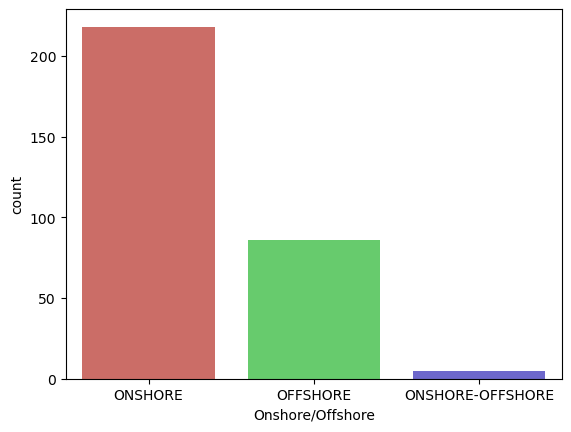

In [691]:
sns.countplot(x=target_col, data=train, palette='hls', hue=target_col, legend=False)
plt.show()

In [692]:
train[target_col].value_counts()

Onshore/Offshore
ONSHORE             218
OFFSHORE             86
ONSHORE-OFFSHORE      5
Name: count, dtype: int64

In [693]:
5/309

0.016181229773462782

Целевая переменная у нас мульти-классовая, причём транзитное расположение (ONSHORE-OFFSHORE) — относится к миноритарному классу, около 2%. 

Здесь видится две стратегии:
* С одной стороны этот признак можно удалить, и тренировать модель на двух мажоритарных классах, чтобы она хотя бы их определяла точно.
* С другой стороны этот признак может быть самым важным и тогда нам важнее, чтобы модель как можно меньше ошибалась на нём, тогда его надо оставить.

Выберем обе стратегии и посмотрим, что получится.

# train_test_split

In [694]:
# Закодируем целевую переменную
# Создание и применение LabelEncoder
encoder = LabelEncoder()
train[target_col] = encoder.fit_transform(train[target_col])

# Создание словаря соответствия
label_mapping = {class_name: index for index, class_name in enumerate(encoder.classes_)}

print('label_mapping')
print(label_mapping)

label_mapping
{'OFFSHORE': 0, 'ONSHORE': 1, 'ONSHORE-OFFSHORE': 2}


In [695]:
train[target_col].value_counts()

Onshore/Offshore
1    218
0     86
2      5
Name: count, dtype: int64

## Разбиение с удалением миноритарного класса

In [696]:
# Оставляем только классы 0 и 1
mask = train[target_col] != 2
train_trim = train[mask]

In [697]:
# Формируем X и y из отфильтрованных данных
X_trim = train_trim.drop(columns=[target_col])
y_trim = train_trim[target_col]

# Разбиваем на train/test
X_train_trim, X_test_trim, y_train_trim, y_test_trim = train_test_split(
    X_trim, y_trim, 
    test_size=0.2, 
    random_state=SEED, 
    stratify=y_trim
)
print(f'Trim training set shape: {X_trim.shape}, {y_trim.shape}')
print(f'Train shape: {X_train_trim.shape}, {y_train_trim.shape}')
print(f'Test shape: {X_test_trim.shape}, {y_test_trim.shape}')

Trim training set shape: (304, 142), (304,)
Train shape: (243, 142), (243,)
Test shape: (61, 142), (61,)


## Разбиение без удаления

In [698]:
# Удаляем целевую переменную из признаков
X = train.copy().drop(columns=[target_col])
y = train[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    random_state=SEED,
                                                    stratify=y,
                                                   )

print(f'All training set shape: {X.shape}, {y.shape}')
print(f'Train shape: {X_train.shape}, {y_train.shape}')
print(f'Test shape: {X_test.shape}, {y_test.shape}')

All training set shape: (309, 142), (309,)
Train shape: (247, 142), (247,)
Test shape: (62, 142), (62,)


In [699]:
y_train.value_counts()

Onshore/Offshore
1    174
0     69
2      4
Name: count, dtype: int64

In [700]:
y_train_trim.value_counts()

Onshore/Offshore
1    174
0     69
Name: count, dtype: int64

In [701]:
y_test.value_counts()

Onshore/Offshore
1    44
0    17
2     1
Name: count, dtype: int64

In [702]:
y_test_trim.value_counts()

Onshore/Offshore
1    44
0    17
Name: count, dtype: int64

In [703]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 247 entries, 88 to 20
Columns: 142 entries, Latitude to Main_Structural_WRENCH
dtypes: float64(6), int64(136)
memory usage: 275.9 KB


In [704]:
X_train_trim.info()

<class 'pandas.DataFrame'>
Index: 243 entries, 43 to 307
Columns: 142 entries, Latitude to Main_Structural_WRENCH
dtypes: float64(6), int64(136)
memory usage: 271.5 KB


In [705]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Columns: 142 entries, Latitude to Main_Structural_WRENCH
dtypes: float64(6), int64(136)
memory usage: 342.9 KB


In [706]:
X_trim.info()

<class 'pandas.DataFrame'>
Index: 304 entries, 0 to 308
Columns: 142 entries, Latitude to Main_Structural_WRENCH
dtypes: float64(6), int64(136)
memory usage: 339.6 KB


**Вывод по разбиению:** — данные разбились корректно.

# Балансировка

## Обзор, начальные действия

Блансировка нужна для повышения точности выбора миноритарного класса. Есть две стратегии: 
* Сокращение мажоритарного класса (Undersampling).
* Увеличение миноритарного (Oversampling).

In [707]:
# Функция для вывода графиков по балансировке клссов
def plot_comparison(df_before, df_after, target_col, mapping=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    
    # 1. Вычисляем общий максимум для единой шкалы Y
    max_count = max(df_before[target_col].value_counts().max(),
                    df_after[target_col].value_counts().max())
    y_limit = max_count * 1.05
    
    # 2. Рисуем графики (сначала создаем их, чтобы появились деления на осях)
    sns.countplot(data=df_before, x=target_col, hue=target_col, 
                  palette='hls', legend=False, ax=axes[0])
    axes[0].set_title('Было')
    
    sns.countplot(data=df_after, x=target_col, hue=target_col, 
                  palette='hls', legend=False, ax=axes[1])
    axes[1].set_title('Стало')

    # 3. Настраиваем оси для обоих графиков
    if mapping:
        inv_mapping = {v: k for k, v in mapping.items()}
        
    for ax in axes:
        ax.set_ylim(0, y_limit)
        if mapping:
            # Сначала фиксируем позиции, чтобы не было Warning
            ticks = ax.get_xticks()
            ax.set_xticks(ticks)
            # Заменяем индексы на названия из маппинга
            labels = [inv_mapping.get(int(t), t) for t in ticks]
            ax.set_xticklabels(labels)

    plt.tight_layout()
    plt.show()


In [708]:
# Объединяем X_train и y_train в один DataFrame
train_df = pd.concat([X_train, y_train], axis='columns')
train_df_trim = pd.concat([X_train_trim, y_train_trim], axis='columns')

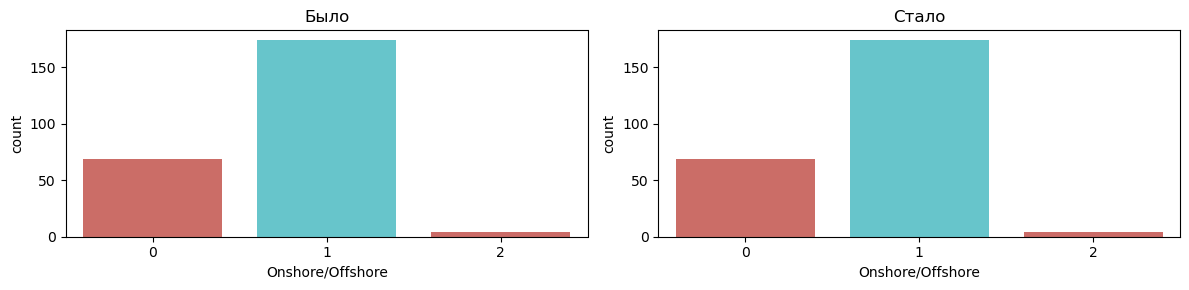

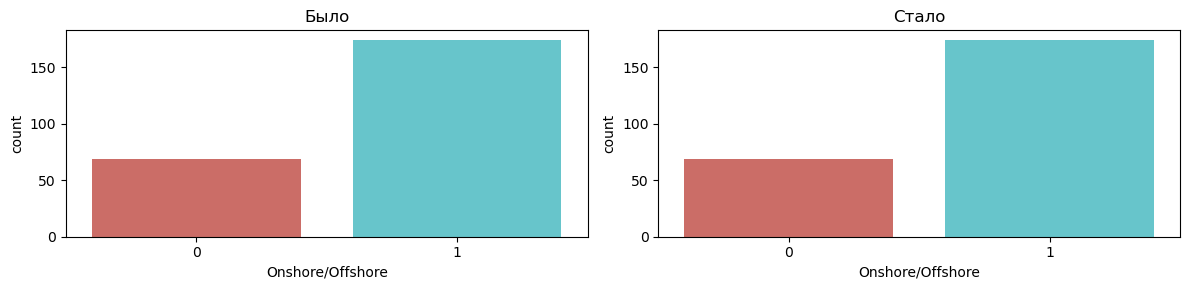

In [709]:
# Выведем графики с тремя класами и с двумя
plot_comparison(train_df, train_df, target_col)
plot_comparison(train_df_trim, train_df_trim, target_col)

In [710]:
train_df

,Latitude,Longitude,Depth,Porosity,Has_Gravity,Has_Evaporite,Has_Compression,log_Thickness (gross average ft),log_Thickness (net pay average ft),log_Permeability,...,Main_Structural_INTRACRATONIC,Main_Structural_INVERSION,Main_Structural_PASSIVE MARGIN,Main_Structural_RIFT,Main_Structural_SALT,Main_Structural_SUB-SALT,Main_Structural_SUB-THRUST,Main_Structural_THRUST,Main_Structural_WRENCH,Onshore/Offshore
88,9.6835,-63.4529,12750,15.0,0,0,1,7.378384,6.746412,6.175867,...,0,0,0,0,0,0,0,1,0,1
97,39.4700,52.7300,10100,18.0,0,0,1,9.012011,5.564520,4.615121,...,0,0,0,0,0,0,0,1,0,0
71,52.2830,-113.5543,4921,13.2,0,0,1,4.753590,2.397895,5.252273,...,0,0,0,0,0,0,0,0,0,1
67,65.0789,7.4898,6480,27.5,0,0,0,6.131226,5.942799,8.635154,...,0,0,0,1,0,0,0,0,0,0
13,54.4995,-115.4904,8540,9.0,0,0,1,5.442418,4.110874,3.828641,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,56.4125,2.0286,7044,13.0,0,0,0,3.433987,3.433987,3.988984,...,0,0,0,1,0,0,0,0,0,0
53,-5.3099,11.9154,3065,24.0,1,0,0,6.111467,5.017280,6.216606,...,0,0,1,0,0,0,0,0,0,0
115,37.0789,-109.2333,5575,14.0,0,0,1,4.394449,3.850148,2.772589,...,1,0,0,0,0,0,0,0,0,1
134,39.5800,53.1300,1800,19.0,0,0,1,8.922792,5.252273,3.433987,...,0,0,0,0,0,0,0,1,0,2


In [711]:
train_df[target_col].value_counts()

Onshore/Offshore
1    174
0     69
2      4
Name: count, dtype: int64

In [712]:
y_train.value_counts()

Onshore/Offshore
1    174
0     69
2      4
Name: count, dtype: int64

## Undersampling 

Сокращение мажоритарного класса

### Случайное удаление (random undesampling)


In [713]:
# Количество объектов для каждого класса (на уровне миноритарного класса)
K = train_df[train_df[target_col] == 2].shape[0]
K

4

In [714]:
# Количество объектов для каждого класса (на уровне миноритарного класса) для обрезанной выборки
K_trim = train_df_trim[train_df_trim[target_col] == 0].shape[0]
K_trim

69

In [715]:
# Сначала для всей выборки
#
# Сэмплируем K объектов для классов 0 и 1
df0 = train_df[train_df[target_col] == 0].sample(K, random_state=SEED)
df1 = train_df[train_df[target_col] == 1].sample(K, random_state=SEED)
#
# Берем все объекты класса 2 (миноритарный класс)
df2 = train_df[train_df[target_col] == 2]

# Потом для обрезанной
#
# Сэмплируем K_trim объектов для класса 1
df1_trim = train_df_trim[train_df_trim[target_col] == 1].sample(K_trim, random_state=SEED)
#
# Берем все объекты класса 0 (миноритарный класс для обрезанной выборки)
df0_trim = train_df_trim[train_df_trim[target_col] == 0]

# Соединяем все вместе
df_random_undersample = pd.concat([df0, df2, df1])
df_random_undersample_trim = pd.concat([df0_trim, df1_trim])

# Разделяем обратно на X_train и y_train
X_train_random_undersample = df_random_undersample.drop(columns=[target_col])
y_train_random_undersample = df_random_undersample[target_col]
X_train_random_undersample_trim = df_random_undersample_trim.drop(columns=[target_col])
y_train_random_undersample_trim = df_random_undersample_trim[target_col]

# Проверка баланса классов
print(y_train_random_undersample.value_counts())
print(y_train_random_undersample_trim.value_counts())

Onshore/Offshore
0    4
2    4
1    4
Name: count, dtype: int64
Onshore/Offshore
0    69
1    69
Name: count, dtype: int64


In [716]:
y_train_random_undersample

170    0
97     0
83     0
184    0
64     2
92     2
185    2
134    2
282    1
143    1
30     1
76     1
Name: Onshore/Offshore, dtype: int64

In [717]:
y_train_random_undersample_trim

97     0
184    0
274    0
241    0
96     0
      ..
39     1
208    1
103    1
305    1
247    1
Name: Onshore/Offshore, Length: 138, dtype: int64

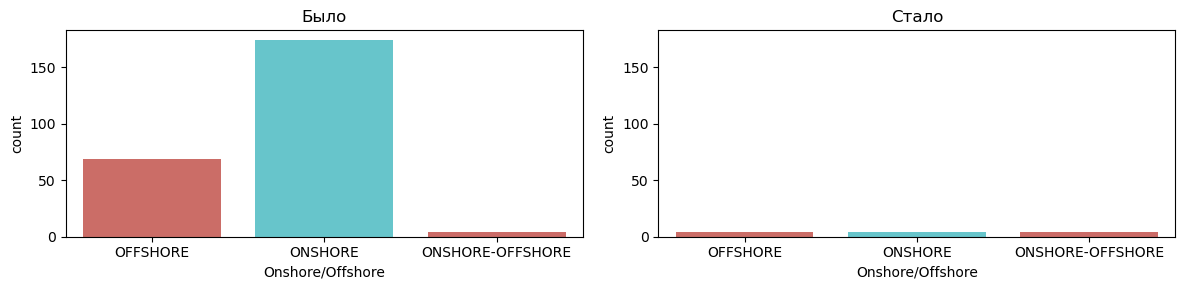

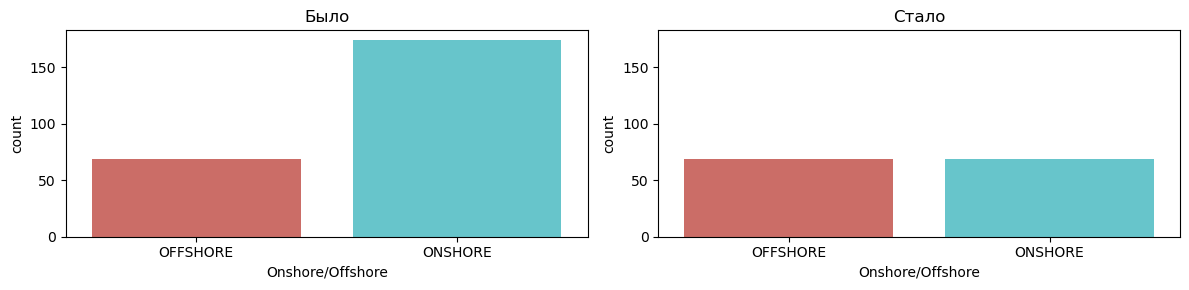

In [718]:
plot_comparison(train_df, df_random_undersample, target_col, mapping=label_mapping)
plot_comparison(train_df_trim, df_random_undersample_trim, target_col, mapping=label_mapping)

Видим, что классы теперь сбалансированы идеально, но в первом случае, большую часть информации мы потеряли.

In [719]:
df_random_undersample

,Latitude,Longitude,Depth,Porosity,Has_Gravity,Has_Evaporite,Has_Compression,log_Thickness (gross average ft),log_Thickness (net pay average ft),log_Permeability,...,Main_Structural_INTRACRATONIC,Main_Structural_INVERSION,Main_Structural_PASSIVE MARGIN,Main_Structural_RIFT,Main_Structural_SALT,Main_Structural_SUB-SALT,Main_Structural_SUB-THRUST,Main_Structural_THRUST,Main_Structural_WRENCH,Onshore/Offshore
170,17.5142,109.0088,11270,12.68,0,0,0,6.532334,5.733341,5.641907,...,0,0,0,1,0,0,0,0,0,0
97,39.4700,52.7300,10100,18.00,0,0,1,9.012011,5.564520,4.615121,...,0,0,0,0,0,0,0,1,0,0
83,-9.5901,128.1538,6660,14.00,0,0,0,6.383507,5.634790,3.367296,...,0,0,0,0,0,0,0,0,1,0
184,-5.8950,107.6981,2310,26.00,0,0,1,7.088409,5.575949,5.707110,...,0,0,0,0,0,0,0,0,0,0
64,50.6672,-2.0278,4954,18.00,0,0,1,6.265301,5.017280,4.615121,...,0,0,0,1,0,0,0,0,0,2
92,9.8667,-63.3333,1400,35.00,0,0,1,6.216606,4.795791,7.090910,...,0,0,0,0,0,0,0,0,1,2
185,44.3367,-1.0959,6550,11.00,0,0,1,7.170888,5.303305,2.397895,...,0,0,0,0,0,0,0,0,0,2
134,39.5800,53.1300,1800,19.00,0,0,1,8.922792,5.252273,3.433987,...,0,0,0,0,0,0,0,1,0,2
282,62.0000,66.5500,8399,15.00,0,0,1,4.709530,4.204693,5.081404,...,1,0,0,0,0,0,0,0,0,1
143,36.2674,-120.3659,500,34.00,0,0,1,6.552508,5.252273,6.746412,...,0,0,0,0,0,0,0,0,1,1


In [720]:
df_random_undersample_trim

,Latitude,Longitude,Depth,Porosity,Has_Gravity,Has_Evaporite,Has_Compression,log_Thickness (gross average ft),log_Thickness (net pay average ft),log_Permeability,...,Main_Structural_INTRACRATONIC,Main_Structural_INVERSION,Main_Structural_PASSIVE MARGIN,Main_Structural_RIFT,Main_Structural_SALT,Main_Structural_SUB-SALT,Main_Structural_SUB-THRUST,Main_Structural_THRUST,Main_Structural_WRENCH,Onshore/Offshore
97,39.4700,52.7300,10100,18.0,0,0,1,9.012011,5.564520,4.615121,...,0,0,0,0,0,0,0,1,0,0
184,-5.8950,107.6981,2310,26.0,0,0,1,7.088409,5.575949,5.707110,...,0,0,0,0,0,0,0,0,0,0
274,-38.3300,148.4170,7677,20.0,0,0,1,4.934474,4.836282,7.090910,...,0,1,0,0,0,0,0,0,0,0
241,5.4658,109.7833,8218,15.0,0,0,1,8.582232,7.998671,4.615121,...,0,0,0,0,0,0,0,0,0,0
96,56.6389,3.3355,9520,21.0,1,0,0,6.685861,6.196444,0.470004,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39,0.7675,101.4334,1960,26.0,0,0,0,6.398595,5.303305,6.216606,...,0,1,0,0,0,0,0,0,0,1
208,44.3344,-105.6783,8650,10.0,0,0,1,4.394449,2.564949,2.772589,...,0,0,0,0,0,0,0,0,0,1
103,56.8646,-120.4777,3800,12.0,0,0,1,4.454347,2.624669,4.795791,...,0,0,0,0,0,0,0,0,0,1
305,76.4462,-108.9172,3390,20.0,0,0,1,4.615121,4.276666,6.340359,...,0,0,0,0,0,0,0,0,0,1


### TomekLinks

Tomek Links идентифицирует пары близких соседей, в которых один пример принадлежит классу меньшинства, а другой - классу большинства. Такие пары соседей называются Tomek Links. После их идентификации удаляется пример из класса большинства, что помогает уменьшить дисбаланс данных.

Процесс начинается с предварительной подготовки данных, должны быть размеченные данные с несбалансированными классами.

Для каждого примера данных мы вычисляем расстояния до всех остальных примеров. Затем для каждого примера из класса меньшинства мы ищем его ближайшего соседа из класса большинства и наоборот. Если расстояние между этими двумя примерами минимальное, они образуют Tomek Link.

После того как все Tomek Links были идентифицированы, мы удаляем примеры, которые находятся на концах этих связей из класса большинства. Это может быть сделано путем создания нового набора данных без этих точек.

In [721]:
# Применяем TomekLinks для очистки границ
tl = TomekLinks()

features_res, labels_res = tl.fit_resample(X_train, y_train)
features_res_trim, labels_res_trim = tl.fit_resample(X_train_trim, y_train_trim)

display(features_res)
display(features_res_trim)

,Latitude,Longitude,Depth,Porosity,Has_Gravity,Has_Evaporite,Has_Compression,log_Thickness (gross average ft),log_Thickness (net pay average ft),log_Permeability,...,Main_Structural_FORELAND,Main_Structural_INTRACRATONIC,Main_Structural_INVERSION,Main_Structural_PASSIVE MARGIN,Main_Structural_RIFT,Main_Structural_SALT,Main_Structural_SUB-SALT,Main_Structural_SUB-THRUST,Main_Structural_THRUST,Main_Structural_WRENCH
0,9.6835,-63.4529,12750,15.0,0,0,1,7.378384,6.746412,6.175867,...,0,0,0,0,0,0,0,0,1,0
1,39.4700,52.7300,10100,18.0,0,0,1,9.012011,5.564520,4.615121,...,0,0,0,0,0,0,0,0,1,0
2,52.2830,-113.5543,4921,13.2,0,0,1,4.753590,2.397895,5.252273,...,1,0,0,0,0,0,0,0,0,0
3,65.0789,7.4898,6480,27.5,0,0,0,6.131226,5.942799,8.635154,...,0,0,0,0,1,0,0,0,0,0
4,54.4995,-115.4904,8540,9.0,0,0,1,5.442418,4.110874,3.828641,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,37.0386,-101.0039,1700,14.0,0,0,1,5.484797,3.828641,1.791759,...,1,0,0,0,0,0,0,0,0,0
208,56.4125,2.0286,7044,13.0,0,0,0,3.433987,3.433987,3.988984,...,0,0,0,0,1,0,0,0,0,0
209,-5.3099,11.9154,3065,24.0,1,0,0,6.111467,5.017280,6.216606,...,0,0,0,1,0,0,0,0,0,0
210,37.0789,-109.2333,5575,14.0,0,0,1,4.394449,3.850148,2.772589,...,0,1,0,0,0,0,0,0,0,0


,Latitude,Longitude,Depth,Porosity,Has_Gravity,Has_Evaporite,Has_Compression,log_Thickness (gross average ft),log_Thickness (net pay average ft),log_Permeability,...,Main_Structural_FORELAND,Main_Structural_INTRACRATONIC,Main_Structural_INVERSION,Main_Structural_PASSIVE MARGIN,Main_Structural_RIFT,Main_Structural_SALT,Main_Structural_SUB-SALT,Main_Structural_SUB-THRUST,Main_Structural_THRUST,Main_Structural_WRENCH
0,53.2642,-110.0276,1900,34.0,0,0,1,4.510860,3.931826,7.601402,...,1,0,0,0,0,0,0,0,0,0
1,39.8015,97.4667,11040,8.5,0,0,1,6.431331,4.753590,1.238374,...,0,0,0,0,0,0,0,0,1,0
2,37.4211,-109.1333,5430,11.0,0,0,1,4.110874,3.931826,1.335001,...,0,1,0,0,0,0,0,0,0,0
3,43.8000,-108.3000,5880,15.0,0,0,1,4.615121,4.189655,1.280934,...,1,0,0,0,0,0,0,0,0,0
4,76.4462,-108.9172,3390,20.0,0,0,1,4.615121,4.276666,6.340359,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221,41.5135,-110.9286,13300,7.0,0,0,1,6.621406,5.568345,0.693147,...,0,0,0,0,0,0,0,1,0,0
222,55.8199,-115.1317,5500,13.5,0,0,1,4.615121,2.708050,5.525453,...,1,0,0,0,0,0,0,0,0,0
223,61.2042,1.8287,7267,27.0,0,0,0,6.552508,6.196444,7.824446,...,0,0,0,0,1,0,0,0,0,0
224,23.4090,72.2020,2906,28.0,0,0,1,5.003946,4.204693,8.922792,...,0,0,0,0,1,0,0,0,0,0


In [722]:
labels_res.value_counts()

Onshore/Offshore
1    155
0     53
2      4
Name: count, dtype: int64

In [723]:
labels_res_trim.value_counts()

Onshore/Offshore
1    157
0     69
Name: count, dtype: int64

In [724]:
# А теперь используем RandomUnderSampler для точной балансировки

rus = RandomUnderSampler(sampling_strategy={0: K, 1: K, 2: K}, random_state=SEED)
rus_trim = RandomUnderSampler(sampling_strategy={0: K_trim, 1: K_trim}, random_state=SEED)


balanced_Tomek, labels_resampled = rus.fit_resample(features_res, labels_res)
balanced_Tomek_trim, labels_resampled_trim = rus_trim.fit_resample(features_res_trim, labels_res_trim)
balanced_Tomek = pd.concat([balanced_Tomek, labels_resampled], axis='columns')
balanced_Tomek_trim = pd.concat([balanced_Tomek_trim, labels_resampled_trim], axis='columns')

# Проверяем баланс классов
display(balanced_Tomek[target_col].value_counts())
display(balanced_Tomek_trim[target_col].value_counts())

Onshore/Offshore
0    4
1    4
2    4
Name: count, dtype: int64

Onshore/Offshore
0    69
1    69
Name: count, dtype: int64

In [725]:
balanced_Tomek

,Latitude,Longitude,Depth,Porosity,Has_Gravity,Has_Evaporite,Has_Compression,log_Thickness (gross average ft),log_Thickness (net pay average ft),log_Permeability,...,Main_Structural_INTRACRATONIC,Main_Structural_INVERSION,Main_Structural_PASSIVE MARGIN,Main_Structural_RIFT,Main_Structural_SALT,Main_Structural_SUB-SALT,Main_Structural_SUB-THRUST,Main_Structural_THRUST,Main_Structural_WRENCH,Onshore/Offshore
100,61.3833,1.5500,7970,24.0,0,0,0,6.165418,5.942799,7.090910,...,0,0,0,1,0,0,0,0,0,0
187,61.1000,1.3167,10525,18.0,0,0,0,6.018593,5.198497,4.615121,...,0,0,0,1,0,0,0,0,0,0
199,56.4844,2.9334,9629,20.0,1,0,0,6.463029,6.311735,0.587787,...,0,0,0,0,1,0,0,0,0,0
71,60.8399,-151.6153,8780,11.0,0,0,1,6.216606,5.673323,4.836282,...,0,1,0,0,0,0,0,0,0,0
18,37.3971,-100.9544,4075,22.0,0,0,1,5.017280,2.397895,4.454347,...,0,0,0,0,0,0,0,0,0,1
12,55.1141,-114.4722,5700,13.0,0,0,1,4.394449,2.639057,5.442418,...,0,0,0,0,0,0,0,0,0,1
152,22.1333,56.0000,4440,28.0,0,0,1,5.860786,5.707110,1.791759,...,0,0,0,0,1,0,0,0,0,1
99,60.8929,109.0385,5216,10.0,0,0,1,5.303305,3.258097,5.347108,...,0,1,0,0,0,0,0,0,0,1
21,50.6672,-2.0278,4954,18.0,0,0,1,6.265301,5.017280,4.615121,...,0,0,0,1,0,0,0,0,0,2
106,44.3367,-1.0959,6550,11.0,0,0,1,7.170888,5.303305,2.397895,...,0,0,0,0,0,0,0,0,0,2


In [726]:
balanced_Tomek_trim

,Latitude,Longitude,Depth,Porosity,Has_Gravity,Has_Evaporite,Has_Compression,log_Thickness (gross average ft),log_Thickness (net pay average ft),log_Permeability,...,Main_Structural_INTRACRATONIC,Main_Structural_INVERSION,Main_Structural_PASSIVE MARGIN,Main_Structural_RIFT,Main_Structural_SALT,Main_Structural_SUB-SALT,Main_Structural_SUB-THRUST,Main_Structural_THRUST,Main_Structural_WRENCH,Onshore/Offshore
99,56.4500,2.2833,11787,20.0,1,0,0,6.478510,5.968708,5.860786,...,0,0,0,0,1,0,0,0,0,0
5,39.4700,52.7300,10100,18.0,0,0,1,9.012011,5.564520,4.615121,...,0,0,0,0,0,0,0,1,0,0
179,35.3676,2.0694,490,25.0,0,0,1,8.476580,5.993961,6.216606,...,0,1,0,0,0,0,0,0,0,0
17,56.6389,3.3355,9520,21.0,1,0,0,6.685861,6.196444,0.470004,...,0,0,0,0,1,0,0,0,0,0
196,-35.2330,21.5100,7306,18.0,0,0,0,4.753590,4.595120,6.216606,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,22.1333,56.0000,4440,28.0,0,0,1,5.860786,5.707110,1.791759,...,0,0,0,0,1,0,0,0,0,1
165,50.6174,-112.2057,3347,26.0,0,0,1,4.151040,2.944439,7.824446,...,0,0,0,0,0,0,0,0,0,1
88,23.4300,72.2800,3136,30.0,0,0,1,6.200509,3.091042,8.294300,...,0,0,0,1,0,0,0,0,0,1
217,38.6216,-81.6611,4850,8.0,0,0,1,3.583519,2.484907,3.349904,...,0,0,0,0,0,0,0,0,0,1


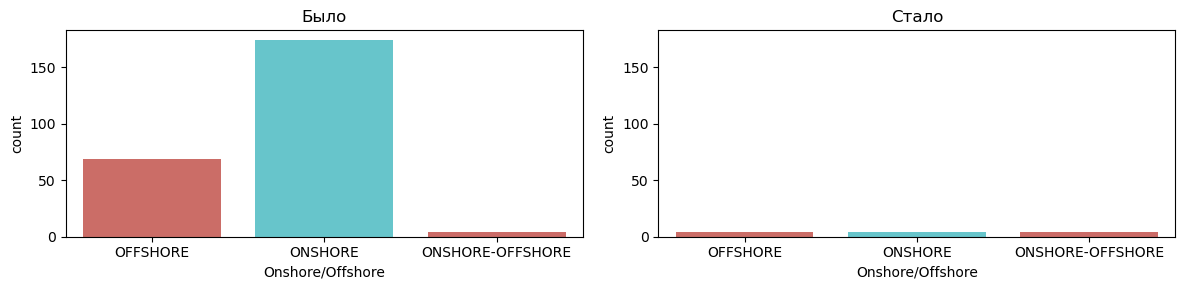

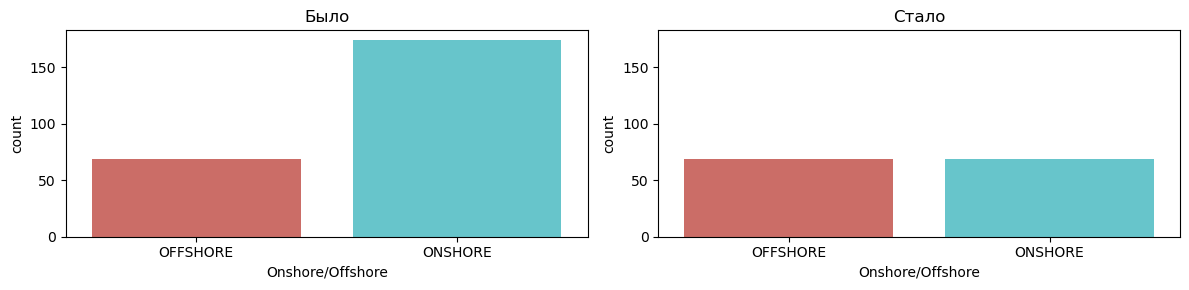

In [727]:
plot_comparison(train_df, balanced_Tomek, target_col, mapping=label_mapping)
plot_comparison(train_df_trim, balanced_Tomek_trim, target_col, mapping=label_mapping)

### NearMiss (ближайшие соседи)

Выбирает объекты из мажоритарного класса, которые ближе всего к миноритарным классам. Есть три стратегии!

- `NearMiss-1`: оставляет объекты, ближайшие к $k$ соседям из меньшинства
- `NearMiss-2`: оставляет объекты, ближайшие к среднему расстоянию
- `NearMiss-3`: оставляет объекты, у которых наиболее близкие соседи из меньшинства

In [728]:
y_train.value_counts()

Onshore/Offshore
1    174
0     69
2      4
Name: count, dtype: int64

In [729]:
y_train_trim.value_counts()

Onshore/Offshore
1    174
0     69
Name: count, dtype: int64

In [730]:

nm = NearMiss(version=1)
df_NearMiss, y_res = nm.fit_resample(X_train, y_train)
df_NearMiss_trim, y_res_trim = nm.fit_resample(X_train_trim, y_train_trim)

df_NearMiss = pd.concat([df_NearMiss, y_res], axis='columns')
df_NearMiss_trim = pd.concat([df_NearMiss_trim, y_res_trim], axis='columns')

display(df_NearMiss[target_col].value_counts())
display(df_NearMiss_trim[target_col].value_counts())

Onshore/Offshore
0    4
1    4
2    4
Name: count, dtype: int64

Onshore/Offshore
0    69
1    69
Name: count, dtype: int64

In [731]:
df_NearMiss.head(3)

,Latitude,Longitude,Depth,Porosity,Has_Gravity,Has_Evaporite,Has_Compression,log_Thickness (gross average ft),log_Thickness (net pay average ft),log_Permeability,...,Main_Structural_INTRACRATONIC,Main_Structural_INVERSION,Main_Structural_PASSIVE MARGIN,Main_Structural_RIFT,Main_Structural_SALT,Main_Structural_SUB-SALT,Main_Structural_SUB-THRUST,Main_Structural_THRUST,Main_Structural_WRENCH,Onshore/Offshore
0,-5.8950,107.6981,2310,26.0,0,0,1,7.088409,5.575949,5.707110,...,0,0,0,0,0,0,0,0,0,0
1,-5.4397,106.2639,2880,18.0,0,0,0,5.303305,4.189655,6.226537,...,0,1,0,0,0,0,0,0,0,0
2,5.6284,114.8906,1180,23.0,1,0,0,8.815815,6.216606,5.525453,...,0,0,0,0,0,0,0,0,0,0


In [732]:
df_NearMiss_trim.head(3)

,Latitude,Longitude,Depth,Porosity,Has_Gravity,Has_Evaporite,Has_Compression,log_Thickness (gross average ft),log_Thickness (net pay average ft),log_Permeability,...,Main_Structural_INTRACRATONIC,Main_Structural_INVERSION,Main_Structural_PASSIVE MARGIN,Main_Structural_RIFT,Main_Structural_SALT,Main_Structural_SUB-SALT,Main_Structural_SUB-THRUST,Main_Structural_THRUST,Main_Structural_WRENCH,Onshore/Offshore
0,39.470,52.7300,10100,18.0,0,0,1,9.012011,5.564520,4.615121,...,0,0,0,0,0,0,0,1,0,0
1,-5.895,107.6981,2310,26.0,0,0,1,7.088409,5.575949,5.707110,...,0,0,0,0,0,0,0,0,0,0
2,-38.330,148.4170,7677,20.0,0,0,1,4.934474,4.836282,7.090910,...,0,1,0,0,0,0,0,0,0,0


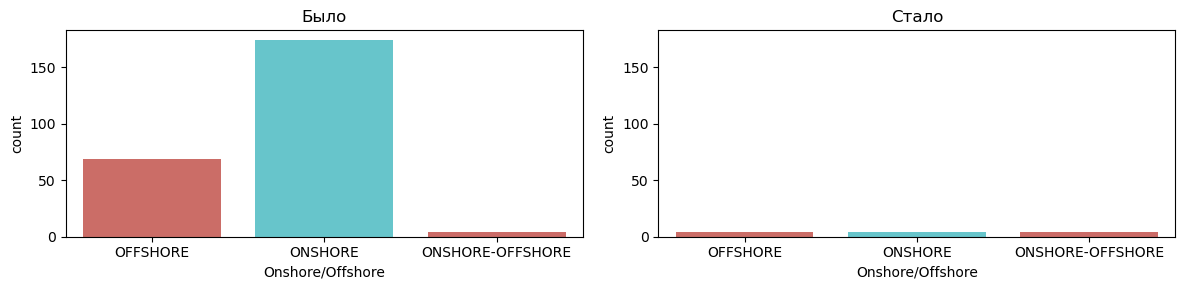

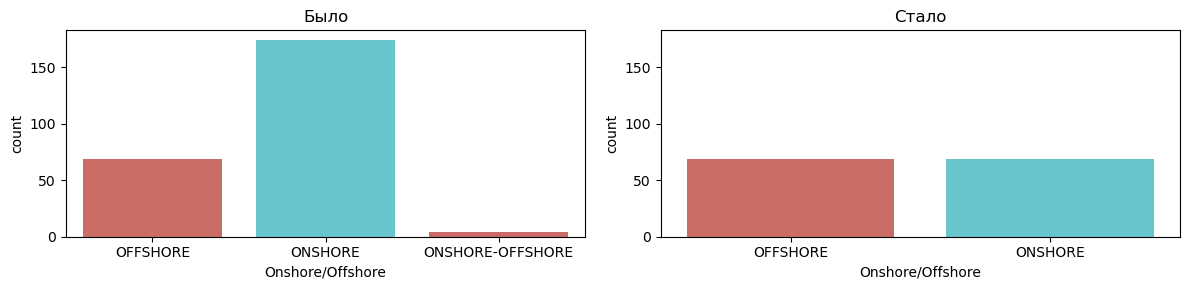

In [733]:
plot_comparison(train_df, df_NearMiss, target_col, mapping=label_mapping)
plot_comparison(train_df, df_NearMiss_trim, target_col, mapping=label_mapping)

## Oversampling

### RandomOverSampler (случайная генерация объектов)

Этот метод просто дублирует случайные объекты из миноритарных классов до нужного количества. Самый простой способ увеличить данные.

In [734]:
# Создаем экземпляр RandomOverSampler
ros = RandomOverSampler(random_state=SEED)

# Применяем oversampling к данным
df_rand_over, y_res = ros.fit_resample(X_train, y_train)
df_rand_over_trim, y_res_trim = ros.fit_resample(X_train_trim, y_train_trim)
df_rand_over = pd.concat([df_rand_over, y_res], axis='columns')
df_rand_over_trim = pd.concat([df_rand_over_trim, y_res_trim], axis='columns')

# Проверка нового распределения классов
display(df_rand_over[target_col].value_counts())
display(df_rand_over_trim[target_col].value_counts())

Onshore/Offshore
1    174
0    174
2    174
Name: count, dtype: int64

Onshore/Offshore
1    174
0    174
Name: count, dtype: int64

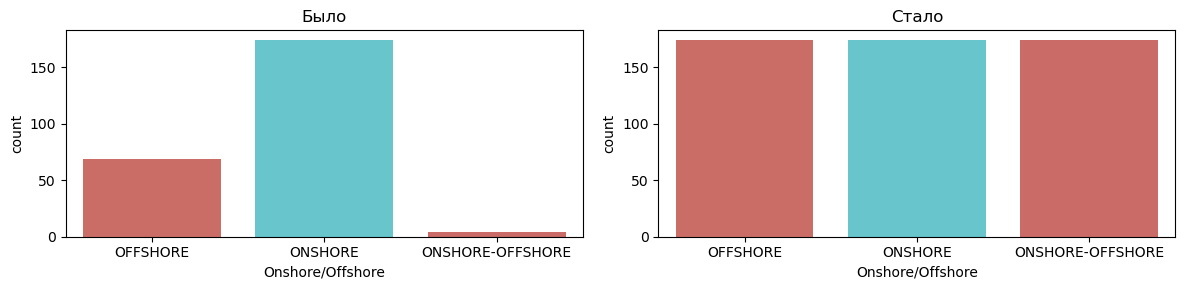

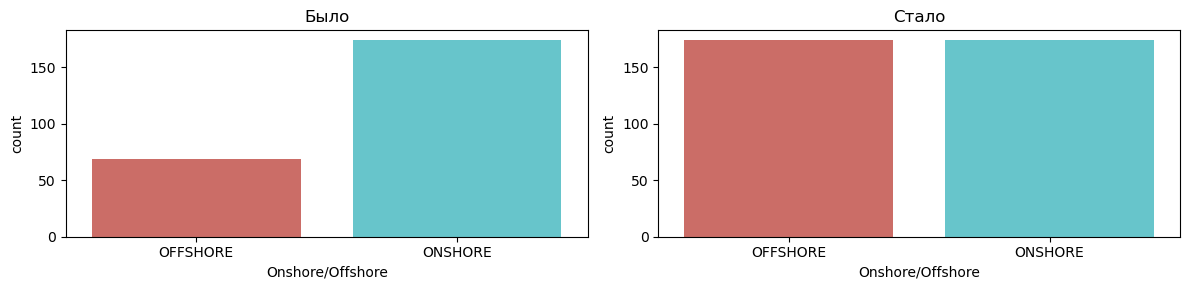

In [735]:
plot_comparison(train_df, df_rand_over, target_col, mapping=label_mapping)
plot_comparison(train_df_trim, df_rand_over_trim, target_col, mapping=label_mapping)

### SMOTE (Synthetic Minority Over-sampling Technique)

In [736]:
print(f'All Features shape: {X.shape}')
print(f'All Target distribution:\n{y.value_counts()}')

print(f'Trimmed Features shape: {X_trim.shape}')
print(f'Trimmed Target distribution:\n{y_trim.value_counts()}')

All Features shape: (309, 142)
All Target distribution:
Onshore/Offshore
1    218
0     86
2      5
Name: count, dtype: int64
Trimmed Features shape: (304, 142)
Trimmed Target distribution:
Onshore/Offshore
1    218
0     86
Name: count, dtype: int64


In [737]:
# Приводим весь датафрейм к float, чтобы избежать конфликта при интерполяции
X_train_float64 = X_train.astype('float64')
X_train_trim_float64 = X_train_trim.astype('float64')

In [738]:
# Применение SMOTE к тренировочным данным
smote = SMOTE(random_state=SEED, k_neighbors=3)
X_train_res, y_train_res = smote.fit_resample(X_train_float64, y_train)
X_train_res_trim, y_train_res_trim = smote.fit_resample(X_train_trim_float64, y_train_trim)

# Собираем всё обратно в DataFrame, если нужно
balanced_df_SMOTE = pd.DataFrame(X_train_res, columns=X.columns)
balanced_df_SMOTE[target_col] = y_train_res

balanced_df_SMOTE_trim = pd.DataFrame(X_train_res_trim, columns=X_trim.columns)
balanced_df_SMOTE_trim[target_col] = y_train_res_trim


display(balanced_df_SMOTE[target_col].value_counts())
display(balanced_df_SMOTE_trim[target_col].value_counts())

Onshore/Offshore
1    174
0    174
2    174
Name: count, dtype: int64

Onshore/Offshore
1    174
0    174
Name: count, dtype: int64

In [739]:
balanced_df_SMOTE.head(3)

,Latitude,Longitude,Depth,Porosity,Has_Gravity,Has_Evaporite,Has_Compression,log_Thickness (gross average ft),log_Thickness (net pay average ft),log_Permeability,...,Main_Structural_INTRACRATONIC,Main_Structural_INVERSION,Main_Structural_PASSIVE MARGIN,Main_Structural_RIFT,Main_Structural_SALT,Main_Structural_SUB-SALT,Main_Structural_SUB-THRUST,Main_Structural_THRUST,Main_Structural_WRENCH,Onshore/Offshore
0,9.6835,-63.4529,12750.0,15.0,0.0,0.0,1.0,7.378384,6.746412,6.175867,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
1,39.4700,52.7300,10100.0,18.0,0.0,0.0,1.0,9.012011,5.564520,4.615121,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
2,52.2830,-113.5543,4921.0,13.2,0.0,0.0,1.0,4.753590,2.397895,5.252273,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [740]:
balanced_df_SMOTE_trim.head(3)

,Latitude,Longitude,Depth,Porosity,Has_Gravity,Has_Evaporite,Has_Compression,log_Thickness (gross average ft),log_Thickness (net pay average ft),log_Permeability,...,Main_Structural_INTRACRATONIC,Main_Structural_INVERSION,Main_Structural_PASSIVE MARGIN,Main_Structural_RIFT,Main_Structural_SALT,Main_Structural_SUB-SALT,Main_Structural_SUB-THRUST,Main_Structural_THRUST,Main_Structural_WRENCH,Onshore/Offshore
0,53.2642,-110.0276,1900.0,34.0,0.0,0.0,1.0,4.510860,3.931826,7.601402,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,39.8015,97.4667,11040.0,8.5,0.0,0.0,1.0,6.431331,4.753590,1.238374,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
2,37.4211,-109.1333,5430.0,11.0,0.0,0.0,1.0,4.110874,3.931826,1.335001,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


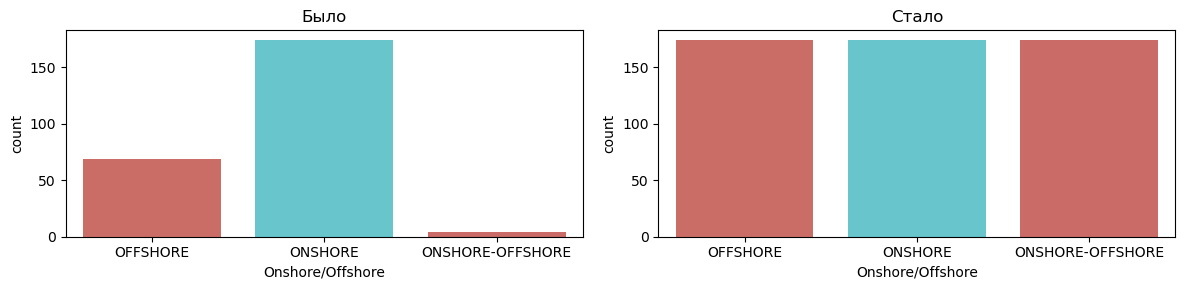

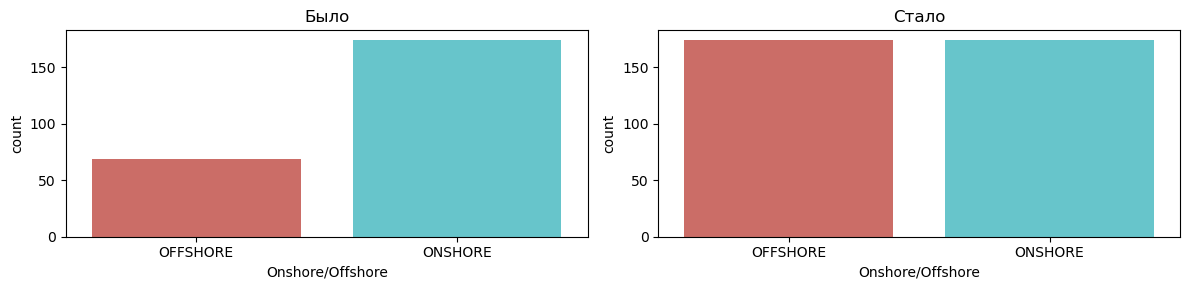

In [741]:
plot_comparison(train_df, balanced_df_SMOTE, target_col, mapping=label_mapping)
plot_comparison(train_df_trim, balanced_df_SMOTE_trim, target_col, mapping=label_mapping)

### ADASYN (Adaptive Synthetic Sampling)

Это улучшенная версия SMOTE, но с умным трюком:

Она генерирует больше синтетических данных для сложных случаев — объектов, которые сложнее классифицировать.

Параметр, *n_neighbors*, не может быть больше меньшей выборки, более 7 может увлечься созданием "синтетических" наборов.

In [742]:
# Создаем экземпляр ADASYN from imblearn.over_sampling

adasyn = ADASYN(random_state=SEED, n_neighbors=3)
adasyn_n5 = ADASYN(random_state=SEED, n_neighbors=5)
adasyn_n7 = ADASYN(random_state=SEED, n_neighbors=7)
adasyn_n11 = ADASYN(random_state=SEED, n_neighbors=11)
adasyn_n13 = ADASYN(random_state=SEED, n_neighbors=13)
adasyn_n17 = ADASYN(random_state=SEED, n_neighbors=17)

# Применяем ADASYN
X_train_ADASYN, y_train_ADASYN = adasyn.fit_resample(X_train_float64, y_train)
X_train_trim_ADASYN, y_train_trim_ADASYN = adasyn.fit_resample(X_train_trim_float64, y_train_trim)
X_train_trim_ADASYN_n5, y_train_trim_ADASYN_n5 = adasyn_n5.fit_resample(X_train_trim_float64, y_train_trim)
X_train_trim_ADASYN_n7, y_train_trim_ADASYN_n7 = adasyn_n7.fit_resample(X_train_trim_float64, y_train_trim)
X_train_trim_ADASYN_n11, y_train_trim_ADASYN_n11 = adasyn_n11.fit_resample(X_train_trim_float64, y_train_trim)
X_train_trim_ADASYN_n13, y_train_trim_ADASYN_n13 = adasyn_n13.fit_resample(X_train_trim_float64, y_train_trim)
X_train_trim_ADASYN_n17, y_train_trim_ADASYN_n17 = adasyn_n17.fit_resample(X_train_trim_float64, y_train_trim)


# Собираем всё обратно в DataFrame, если нужно
balanced_df_ADASYN = pd.DataFrame(X_train_ADASYN, columns=X.columns)
balanced_df_ADASYN[target_col] = y_train_ADASYN

balanced_df_trim_ADASYN = pd.DataFrame(X_train_trim_ADASYN, columns=X_trim.columns)
balanced_df_trim_ADASYN[target_col] = y_train_trim_ADASYN

balanced_df_trim_ADASYN_n5 = pd.DataFrame(X_train_trim_ADASYN_n5, columns=X_trim.columns)
balanced_df_trim_ADASYN_n5[target_col] = y_train_trim_ADASYN_n5

balanced_df_trim_ADASYN_n7 = pd.DataFrame(X_train_trim_ADASYN_n7, columns=X_trim.columns)
balanced_df_trim_ADASYN_n11 = pd.DataFrame(X_train_trim_ADASYN_n11, columns=X_trim.columns)
balanced_df_trim_ADASYN_n13 = pd.DataFrame(X_train_trim_ADASYN_n13, columns=X_trim.columns)
balanced_df_trim_ADASYN_n17 = pd.DataFrame(X_train_trim_ADASYN_n17, columns=X_trim.columns)

balanced_df_trim_ADASYN_n7[target_col] = y_train_trim_ADASYN_n7
balanced_df_trim_ADASYN_n11[target_col] = y_train_trim_ADASYN_n11
balanced_df_trim_ADASYN_n13[target_col] = y_train_trim_ADASYN_n13
balanced_df_trim_ADASYN_n17[target_col] = y_train_trim_ADASYN_n17


display(balanced_df_ADASYN[target_col].value_counts())
display(balanced_df_trim_ADASYN[target_col].value_counts())
display(balanced_df_trim_ADASYN_n5[target_col].value_counts())
display(balanced_df_trim_ADASYN_n7[target_col].value_counts())
display(balanced_df_trim_ADASYN_n11[target_col].value_counts())
display(balanced_df_trim_ADASYN_n13[target_col].value_counts())
display(balanced_df_trim_ADASYN_n17[target_col].value_counts())


Onshore/Offshore
0    188
1    174
2    172
Name: count, dtype: int64

Onshore/Offshore
0    188
1    174
Name: count, dtype: int64

Onshore/Offshore
0    191
1    174
Name: count, dtype: int64

Onshore/Offshore
1    174
0    167
Name: count, dtype: int64

Onshore/Offshore
0    181
1    174
Name: count, dtype: int64

Onshore/Offshore
1    174
0    174
Name: count, dtype: int64

Onshore/Offshore
0    177
1    174
Name: count, dtype: int64

In [743]:
balanced_df_ADASYN.head(3)

,Latitude,Longitude,Depth,Porosity,Has_Gravity,Has_Evaporite,Has_Compression,log_Thickness (gross average ft),log_Thickness (net pay average ft),log_Permeability,...,Main_Structural_INTRACRATONIC,Main_Structural_INVERSION,Main_Structural_PASSIVE MARGIN,Main_Structural_RIFT,Main_Structural_SALT,Main_Structural_SUB-SALT,Main_Structural_SUB-THRUST,Main_Structural_THRUST,Main_Structural_WRENCH,Onshore/Offshore
0,9.6835,-63.4529,12750.0,15.0,0.0,0.0,1.0,7.378384,6.746412,6.175867,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
1,39.4700,52.7300,10100.0,18.0,0.0,0.0,1.0,9.012011,5.564520,4.615121,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
2,52.2830,-113.5543,4921.0,13.2,0.0,0.0,1.0,4.753590,2.397895,5.252273,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [744]:
balanced_df_trim_ADASYN.head(3)

,Latitude,Longitude,Depth,Porosity,Has_Gravity,Has_Evaporite,Has_Compression,log_Thickness (gross average ft),log_Thickness (net pay average ft),log_Permeability,...,Main_Structural_INTRACRATONIC,Main_Structural_INVERSION,Main_Structural_PASSIVE MARGIN,Main_Structural_RIFT,Main_Structural_SALT,Main_Structural_SUB-SALT,Main_Structural_SUB-THRUST,Main_Structural_THRUST,Main_Structural_WRENCH,Onshore/Offshore
0,53.2642,-110.0276,1900.0,34.0,0.0,0.0,1.0,4.510860,3.931826,7.601402,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,39.8015,97.4667,11040.0,8.5,0.0,0.0,1.0,6.431331,4.753590,1.238374,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
2,37.4211,-109.1333,5430.0,11.0,0.0,0.0,1.0,4.110874,3.931826,1.335001,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


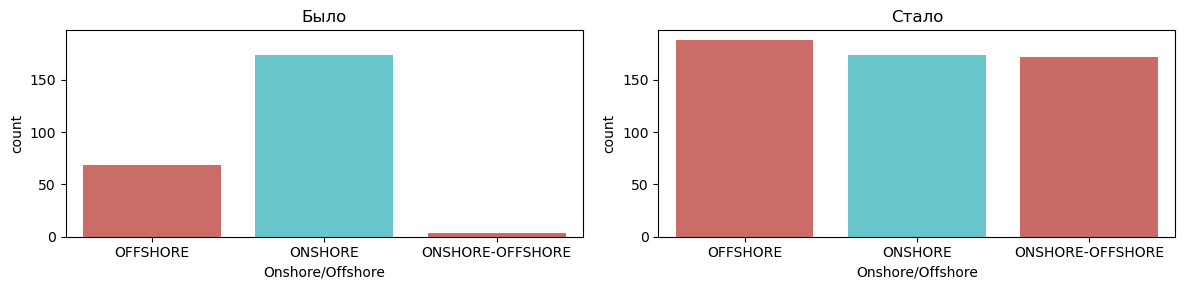

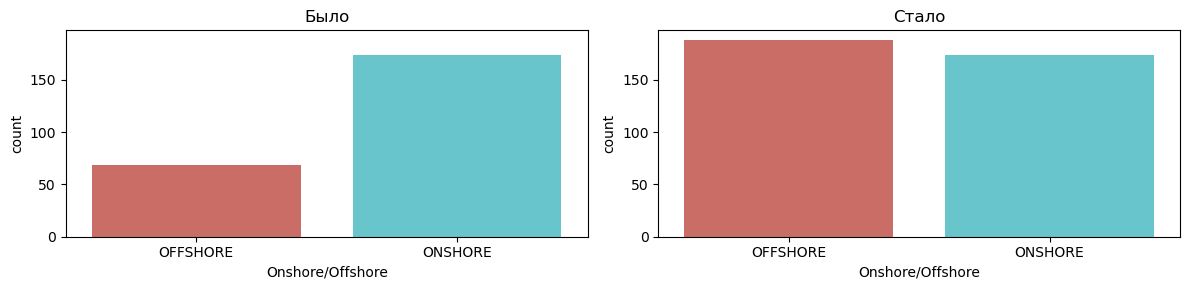

In [745]:
plot_comparison(train_df, balanced_df_ADASYN, target_col, mapping=label_mapping)
plot_comparison(train_df_trim, balanced_df_trim_ADASYN, target_col, mapping=label_mapping)

## Вывод по балансировке

Технически, балансировка по известным алгоритмам и по разным выборкам — удалась.

Проверим модель по пяти фолдам, чтобы не звисить от случайного разбиения.

In [746]:
# Создаем пайплайн: сначала балансировка, затем модель
pipeline = Pipeline([
    ('balancing', ADASYN(n_neighbors=5, random_state=SEED)),
    ('classifier', DecisionTreeClassifier(random_state=SEED))
])

# Запускаем кросс-валидацию
# cv=5 означает, что данные разобьются на 5 частей, и мы получим 5 оценок
scores = cross_val_score(pipeline, X_train_trim, y_train_trim, cv=5, scoring='f1_macro')

# Выводим результаты
print(f"Результаты по фолдам: {scores}")
print(f"Средний F1: {scores.mean():.4f}")
print(f"Разброс (стабильность): {scores.std():.4f}")


Результаты по фолдам: [0.81439394 0.79059829 0.89529915 0.89915966 0.85454545]
Средний F1: 0.8508
Разброс (стабильность): 0.0431


**Вывод:** разброс небольшой, данные стабильны.

# Обучение и тестирование моделей

## Дерево решений

In [747]:
# Функция для обучения и оценки модели
def train_and_evaluate(
    X_train, y_train, X_test, y_test, 
    strategy_name, 
    print_res=True, 
    model_type=None, # DecisionTreeClassifier with default parameters
    KNN_max=2,
    max_depth=None,
    min_samples_leaf=2,
):

    # Создаем и обучаем модель
    model_name = model_type or 'DTC'

    if model_type == 'KNN':
        model = KNeighborsClassifier(n_neighbors=KNN_max)
        model_name += '-' + str(KNN_max)
    elif model_type == 'DTC':
        model = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=SEED)
        model_name += '_d-' + str(max_depth) + '_l-' + str(min_samples_leaf)
    else:
        model = DecisionTreeClassifier(random_state=SEED)
        
    model.fit(X_train, y_train)

    # Делаем предсказания на тестовых данных
    y_pred = model.predict(X_test)

    # Выводим результаты
    if print_res:
        print(f"Результаты для стратегии: {strategy_name}")
        print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
        # {‘micro’, ‘macro’, ‘samples’, ‘weighted’, ‘binary’}
        print(f"f1_score macro: {f1_score(y_test, y_pred, average = 'macro', zero_division=0):.4f}")
        print(f"f1_score_weighted: {f1_score(y_test, y_pred, average = 'weighted', zero_division=0):.4f}")
    
        print("\nClassification Report:\n")
        print(classification_report(y_test, y_pred, zero_division=0))
        print("="*60)

    res = {'model_name': model_name,
           # 'model': model,
           'strategy_name': strategy_name,
           'Accuracy': accuracy_score(y_test, y_pred),
           "f1_score_macro": f1_score(y_test, y_pred, average = 'macro', zero_division=0),
           "f1_score_weighted": f1_score(y_test, y_pred, average = 'weighted', zero_division=0),
          }

    return res

In [748]:
# Словарь с датасетами
datasets = {
    'Исходная выбока': (
        X_train, 
        y_train,
    ),
    'Исходная выбока (trim)': (
        X_train_trim, 
        y_train_trim,
    ),
    "Random Undersampling": (
        df_random_undersample.drop(columns=[target_col]), 
        df_random_undersample[target_col],
    ),
    "Random Undersampling Trim": (
        df_random_undersample_trim.drop(columns=[target_col]), 
        df_random_undersample_trim[target_col],
    ),
    "Tomek Links + Random Undersampling": (
        balanced_Tomek.drop(columns=[target_col]), 
        balanced_Tomek[target_col],
    ),
    "Tomek Links + Random Undersampling Trim": (
        balanced_Tomek_trim.drop(columns=[target_col]), 
        balanced_Tomek_trim[target_col],
    ),
    "NearMiss": (
        df_NearMiss.drop(columns=[target_col]), 
        df_NearMiss[target_col],
    ),
    "NearMiss Trim": (
        df_NearMiss_trim.drop(columns=[target_col]), 
        df_NearMiss_trim[target_col],
    ),
    "Random Oversampling": (
        df_rand_over.drop(columns=[target_col]), 
        df_rand_over[target_col],
    ),
    "Random Oversampling Trim": (
        df_rand_over_trim.drop(columns=[target_col]), 
        df_rand_over_trim[target_col],
    ),
    "SMOTE": (
        balanced_df_SMOTE.drop(columns=[target_col]),
        balanced_df_SMOTE[target_col],
    ),
    "SMOTE Trim": (
        balanced_df_SMOTE_trim.drop(columns=[target_col]),
        balanced_df_SMOTE_trim[target_col],
    ),
    "ADASYN": (
        balanced_df_ADASYN.drop(columns=[target_col]),
        balanced_df_ADASYN[target_col],
    ),
    "ADASYN Trim": (
        balanced_df_trim_ADASYN.drop(columns=[target_col]),
        balanced_df_trim_ADASYN[target_col],
    ),
    "ADASYN_n5 Trim": (
        balanced_df_trim_ADASYN_n5.drop(columns=[target_col]),
        balanced_df_trim_ADASYN_n5[target_col],
    ),
    "ADASYN_n7 Trim": (
        balanced_df_trim_ADASYN_n7.drop(columns=[target_col]),
        balanced_df_trim_ADASYN_n7[target_col],
    ),
    "ADASYN_n11 Trim": (
        balanced_df_trim_ADASYN_n11.drop(columns=[target_col]),
        balanced_df_trim_ADASYN_n11[target_col],
    ),
    "ADASYN_n13 Trim": (
        balanced_df_trim_ADASYN_n13.drop(columns=[target_col]),
        balanced_df_trim_ADASYN_n13[target_col],
    ),
    "ADASYN_n17 Trim": (
        balanced_df_trim_ADASYN_n17.drop(columns=[target_col]),
        balanced_df_trim_ADASYN_n17[target_col],
    ),
}

In [749]:
results = []
# переберем параметры для KNN
max_KNN = 12 # max 12 else error
max_KNN_trim = 37
for i in range(2, max_KNN_trim): # max 12 else error
    for strategy, (X_balanced, y_balanced) in datasets.items():
        
        X_test_select = X_test_trim if "Trim" in strategy else X_test
        y_test_select = y_test_trim if "Trim" in strategy else y_test
        
        results.append(
            train_and_evaluate(
                X_balanced, y_balanced, X_test_select, y_test_select, 
                strategy, print_res=False, 
                model_type='KNN', KNN_max = min(i, max_KNN_trim if "Trim" in strategy else max_KNN)
            )
        )

display("KNN")
display(pd.DataFrame(results).describe())

# Добавим DecisionTreeClassifier
# 
# Задаем списки значений, которые хотим проверить
max_depth_values = [2, 3, 4, 5, 6, 7, 10, None]
min_samples_leaf_values = [1, 2, 3, 4, 5, 7, 10, 15, 20]

# Вложенные циклы для перебора комбинаций
for depth in max_depth_values:
    for leaf in min_samples_leaf_values:
        for strategy, (X_balanced, y_balanced) in datasets.items():

            X_test_select = X_test_trim if "Trim" in strategy else X_test
            y_test_select = y_test_trim if "Trim" in strategy else y_test
            
            results.append( train_and_evaluate(
                X_balanced, y_balanced, X_test_select, y_test_select, strategy, print_res=False,
                model_type='DTC',
                max_depth=depth,
                min_samples_leaf=leaf,
            ))

for strategy, (X_balanced, y_balanced) in datasets.items():
    
    X_test_select = X_test_trim if "Trim" in strategy else X_test
    y_test_select = y_test_trim if "Trim" in strategy else y_test
    
    results.append(train_and_evaluate(X_balanced, y_balanced, X_test_select, y_test_select, strategy, print_res=False))

scores = pd.DataFrame(results)
display(scores.T)
display(scores.describe())

'KNN'

,Accuracy,f1_score_macro,f1_score_weighted
count,665.000000,665.000000,665.000000
mean,0.507120,0.433797,0.498812
std,0.127835,0.145071,0.165858
min,0.080645,0.090869,0.090144
25%,0.442623,0.341420,0.449836
50%,0.524590,0.486839,0.544350
75%,0.590164,0.545153,0.608153
max,0.709677,0.671206,0.704606


,0,1,2,3,4,5,6,7,8,9,...,2042,2043,2044,2045,2046,2047,2048,2049,2050,2051
model_name,KNN-2,KNN-2,KNN-2,KNN-2,KNN-2,KNN-2,KNN-2,KNN-2,KNN-2,KNN-2,...,DTC,DTC,DTC,DTC,DTC,DTC,DTC,DTC,DTC,DTC
strategy_name,Исходная выбока,Исходная выбока (trim),Random Undersampling,Random Undersampling Trim,Tomek Links + Random Undersampling,Tomek Links + Random Undersampling Trim,NearMiss,NearMiss Trim,Random Oversampling,Random Oversampling Trim,...,Random Oversampling Trim,SMOTE,SMOTE Trim,ADASYN,ADASYN Trim,ADASYN_n5 Trim,ADASYN_n7 Trim,ADASYN_n11 Trim,ADASYN_n13 Trim,ADASYN_n17 Trim
Accuracy,0.580645,0.564516,0.290323,0.409836,0.451613,0.393443,0.080645,0.377049,0.564516,0.57377,...,0.836066,0.822581,0.819672,0.854839,0.868852,0.852459,0.836066,0.836066,0.836066,0.819672
f1_score_macro,0.375,0.365876,0.203106,0.408405,0.38535,0.39279,0.091005,0.368736,0.368994,0.553491,...,0.808897,0.542448,0.779639,0.550649,0.842377,0.825437,0.802972,0.802972,0.802972,0.786645
f1_score_weighted,0.59879,0.583439,0.263846,0.395527,0.470778,0.383978,0.094214,0.336673,0.586003,0.59561,...,0.840791,0.825335,0.821212,0.848848,0.87097,0.855837,0.838713,0.838713,0.838713,0.8238


,Accuracy,f1_score_macro,f1_score_weighted
count,2052.000000,2052.000000,2052.000000
mean,0.655219,0.559362,0.651848
std,0.187250,0.206389,0.213021
min,0.080645,0.090869,0.090144
25%,0.524590,0.438449,0.544350
50%,0.754098,0.534920,0.764218
75%,0.803279,0.763566,0.808949
max,0.885246,0.859770,0.886226


In [750]:
# Выведем все модели, которые  получили максимальный скор в трёх категориях
metrics = ['Accuracy', 'f1_score_macro', 'f1_score_weighted']
for metric in metrics:
    display(metric + ':')
    display( scores[scores[metric] == scores[metric].max()] )

'Accuracy:'

,model_name,strategy_name,Accuracy,f1_score_macro,f1_score_weighted
1613,DTC_d-7_l-5,ADASYN_n13 Trim,0.885246,0.85977,0.886226
1784,DTC_d-10_l-5,ADASYN_n13 Trim,0.885246,0.85977,0.886226
1955,DTC_d-None_l-5,ADASYN_n13 Trim,0.885246,0.85977,0.886226


'f1_score_macro:'

,model_name,strategy_name,Accuracy,f1_score_macro,f1_score_weighted
1613,DTC_d-7_l-5,ADASYN_n13 Trim,0.885246,0.85977,0.886226
1784,DTC_d-10_l-5,ADASYN_n13 Trim,0.885246,0.85977,0.886226
1955,DTC_d-None_l-5,ADASYN_n13 Trim,0.885246,0.85977,0.886226


'f1_score_weighted:'

,model_name,strategy_name,Accuracy,f1_score_macro,f1_score_weighted
1613,DTC_d-7_l-5,ADASYN_n13 Trim,0.885246,0.85977,0.886226
1784,DTC_d-10_l-5,ADASYN_n13 Trim,0.885246,0.85977,0.886226
1955,DTC_d-None_l-5,ADASYN_n13 Trim,0.885246,0.85977,0.886226


DTC_d-7_l-5	ADASYN_n13 Trim	0.885246	0.85977	0.886226   SEED==42


**Примечание:** при разных *SEED* в топ выбиваются разные модели, что может говорить о зависимости модели от конкретных данных или переобучении.

In [751]:
scores.sort_values(
    by=['f1_score_macro', 'f1_score_weighted', 'Accuracy'],
    ascending=False,
).head(3)

,model_name,strategy_name,Accuracy,f1_score_macro,f1_score_weighted
1613,DTC_d-7_l-5,ADASYN_n13 Trim,0.885246,0.85977,0.886226
1784,DTC_d-10_l-5,ADASYN_n13 Trim,0.885246,0.85977,0.886226
1955,DTC_d-None_l-5,ADASYN_n13 Trim,0.885246,0.85977,0.886226


Лучший результат показало Дерево решений с балансировкой ADASYN, при k=3 (другие k подобрать не получится, так как у нас в выборке только 4 объекта миноритарного класса, а алгоритм требует, чтобы k было меньше или равно).

При этом, несколько параметров Дерева решений дало лучший результат. Выберем тот, у кого глубина меньше, а экземпляров в листе больше, так как эти параметры менее склонны к переобучению.

In [752]:
best_max_depth = 7
best_min_samples_leaf = 5

## Случайный лес

Ключевым недостатком деревьев решений является их «склонность» к переобучению, а также тот факт, что даже при небольшом изменении обучающей выборки дерево может значительно измениться. Однако объединение деревьев в ансамбли или композиции на практике дает очень хорошие результаты.

В задачах классификации рекомендуется брать $m = \sqrt{d}$, где $d$ - общее число признаков, и строить дерево до тех пор, пока в каждом листе не останется по одному объекту, а в задаче регрессии принимать $m = d/3$ и строить дерево, пока в листьях не останется по пять объектов.

In [753]:
(X_train.shape[1])**(1/2), (X_train_trim.shape[1])**(1/2)


(11.916375287812984, 11.916375287812984)

In [754]:
scores[scores['strategy_name'] == 'Исходная выбока'].sort_values(
    by=['f1_score_weighted', 'f1_score_macro', 'Accuracy'],
    ascending=False,
).head(10)

,model_name,strategy_name,Accuracy,f1_score_macro,f1_score_weighted
1273,DTC_d-5_l-7,Исходная выбока,0.854839,0.550366,0.845135
1444,DTC_d-6_l-7,Исходная выбока,0.854839,0.550366,0.845135
1615,DTC_d-7_l-7,Исходная выбока,0.854839,0.550366,0.845135
1786,DTC_d-10_l-7,Исходная выбока,0.854839,0.550366,0.845135
1957,DTC_d-None_l-7,Исходная выбока,0.854839,0.550366,0.845135
1292,DTC_d-5_l-10,Исходная выбока,0.838710,0.534920,0.831461
1463,DTC_d-6_l-10,Исходная выбока,0.838710,0.534920,0.831461
1634,DTC_d-7_l-10,Исходная выбока,0.838710,0.534920,0.831461
1805,DTC_d-10_l-10,Исходная выбока,0.838710,0.534920,0.831461
1976,DTC_d-None_l-10,Исходная выбока,0.838710,0.534920,0.831461


In [755]:
# Создание и обучение модели
clf = RandomForestClassifier(
    n_estimators=100, criterion='gini', random_state=SEED,
    n_jobs=-1, # использовать все ядра
    max_features='log2',
)
clf.fit(X_train, y_train)

# Создание и обучение модели с параметром _balanced
clf_balanced = RandomForestClassifier(
    n_estimators=100, criterion='gini', random_state=SEED,
    n_jobs=-1, # использовать все ядра
    max_features='log2',
    class_weight='balanced',
)
clf_balanced.fit(X_train, y_train)

# Создание и обучение модели без мироритарного класса
clf_trim = RandomForestClassifier(
    n_estimators=100, criterion='gini', random_state=SEED,
    n_jobs=-1, # использовать все ядра
    max_features='log2',
)
clf_trim.fit(X_train_trim, y_train_trim)

# Создание и обучение модели без мироритарного класса с параметром _balanced
clf_trim_balanced = RandomForestClassifier(
    n_estimators=100, criterion='gini', random_state=SEED,
    n_jobs=-1, # использовать все ядра
    max_features='log2',
    class_weight='balanced',
)
clf_trim_balanced.fit(X_train_trim, y_train_trim)

# Предсказание и оценка качества модели
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1_score_macro = f1_score(y_test, y_pred, average = 'macro', zero_division=0)
f1_score_weighted = f1_score(y_test, y_pred, average = 'weighted', zero_division=0)

# Предсказание и оценка качества модели без миноритарного класса
y_pred_clf_trim = clf_trim.predict(X_test_trim)
accuracy_trim = accuracy_score(y_test_trim, y_pred_clf_trim)
f1_score_macro_trim = f1_score(y_test_trim, y_pred_clf_trim, average = 'macro', zero_division=0)
f1_score_weighted_trim = f1_score(y_test_trim, y_pred_clf_trim, average = 'weighted', zero_division=0)

# Предсказание и оценка качества модели без миноритарного класса _balanced
y_pred_clf_trim_balanced = clf_trim_balanced.predict(X_test_trim)
accuracy_trim_balanced = accuracy_score(y_test_trim, y_pred_clf_trim_balanced)
f1_score_macro_trim_balanced = f1_score(y_test_trim, y_pred_clf_trim_balanced, average = 'macro', zero_division=0)
f1_score_weighted_trim_balanced = f1_score(y_test_trim, y_pred_clf_trim_balanced, average = 'weighted', zero_division=0)

# Предсказание и оценка качества модели _balanced
y_pred_balanced = clf.predict(X_test)
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
f1_score_macro_balanced = f1_score(y_test, y_pred_balanced, average = 'macro', zero_division=0)
f1_score_weighted_balanced = f1_score(y_test, y_pred_balanced, average = 'weighted', zero_division=0)

print(f'Точность без обрезки, f1_macro, f1_weighted: {accuracy:.4f}, {f1_score_macro:.4f}, {f1_score_weighted:.4f}')
print(f'Точность с обрезкой, f1_macro, f1_weighted: {accuracy_trim:.4f}, {f1_score_macro_trim:.4f}, {f1_score_weighted_trim:.4f}')
print(f'Точность _balanced, f1_macro, f1_weighted: {accuracy_balanced:.4f}, {f1_score_macro_balanced:.4f}, {f1_score_weighted_balanced:.4f}')
print(f'Точность с обрезкой _balanced, f1_macro, f1_weighted: {accuracy_trim_balanced:.4f}, {f1_score_macro_trim_balanced:.4f}, {f1_score_weighted_trim_balanced:.4f}')


Точность без обрезки, f1_macro, f1_weighted: 0.9032, 0.5879, 0.8913
Точность с обрезкой, f1_macro, f1_weighted: 0.8689, 0.8306, 0.8662
Точность _balanced, f1_macro, f1_weighted: 0.9032, 0.5879, 0.8913
Точность с обрезкой _balanced, f1_macro, f1_weighted: 0.8852, 0.8546, 0.8842


Пока лучший результат на тесте, при SEED=42:
* Точность без обрезки, f1_macro, f1_weighted: 0.9032, 0.5912, 0.8934
* Точность с обрезкой, f1_macro, f1_weighted: 0.8852, 0.8546, 0.8842
* Точность _balanced, f1_macro, f1_weighted: 0.9032, 0.5912, 0.8934


Возьмём сбалансированные классы

In [756]:
scores[scores['strategy_name'] == 'ADASYN'].sort_values(
    by=['f1_score_macro', 'f1_score_weighted', 'Accuracy'],
    ascending=False,
).head(3)

,model_name,strategy_name,Accuracy,f1_score_macro,f1_score_weighted
1608,DTC_d-7_l-5,ADASYN,0.870968,0.565773,0.865839
1703,DTC_d-10_l-1,ADASYN,0.870968,0.565773,0.865839
1779,DTC_d-10_l-5,ADASYN,0.870968,0.565773,0.865839


In [757]:
scores[scores['strategy_name'] == 'ADASYN_n13 Trim'].sort_values(
    by=['f1_score_macro', 'f1_score_weighted', 'Accuracy'],
    ascending=False,
).head(3)

,model_name,strategy_name,Accuracy,f1_score_macro,f1_score_weighted
1613,DTC_d-7_l-5,ADASYN_n13 Trim,0.885246,0.85977,0.886226
1784,DTC_d-10_l-5,ADASYN_n13 Trim,0.885246,0.85977,0.886226
1955,DTC_d-None_l-5,ADASYN_n13 Trim,0.885246,0.85977,0.886226


In [758]:
scores[scores['strategy_name'] == 'ADASYN_n5 Trim'].sort_values(
    by=['f1_score_macro', 'f1_score_weighted', 'Accuracy'],
    ascending=False,
).head(3)

,model_name,strategy_name,Accuracy,f1_score_macro,f1_score_weighted
1610,DTC_d-7_l-5,ADASYN_n5 Trim,0.868852,0.842377,0.87097
1781,DTC_d-10_l-5,ADASYN_n5 Trim,0.868852,0.842377,0.87097
1952,DTC_d-None_l-5,ADASYN_n5 Trim,0.868852,0.842377,0.87097


Выберем ADASYN_n5, так как меньший параметр, менее склонен к переобучению. 

In [759]:
# Создание и обучение модели без мироритарного класса
clf_trim = RandomForestClassifier(
    n_estimators=100, criterion='gini', random_state=SEED,
    n_jobs=-1, # использовать все ядра
    max_features='log2',
)
# Обучение модели
clf_trim.fit(X_train_trim_ADASYN_n5, y_train_trim_ADASYN_n5)

# Предсказание и оценка качества модели
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1_score_macro = f1_score(y_test, y_pred, average = 'macro', zero_division=0)
f1_score_weighted = f1_score(y_test, y_pred, average = 'weighted', zero_division=0)

# Предсказание и оценка качества модели
y_pred_clf_trim = clf_trim.predict(X_test_trim)
accuracy_clf_trim = accuracy_score(y_test_trim, y_pred_clf_trim)
f1_score_macro_clf_trim = f1_score(y_test_trim, y_pred_clf_trim, average = 'macro', zero_division=0)
f1_score_weighted_clf_trim = f1_score(y_test_trim, y_pred_clf_trim, average = 'weighted', zero_division=0)


print(f'Точность, f1_macro, f1_weighted: {accuracy:.4f}, {f1_score_macro:.4f}, {f1_score_weighted:.4f}')
print(f'Точность_trim, f1_macro, f1_weighted: {accuracy_clf_trim:.4f}, {f1_score_macro_clf_trim:.4f}, {f1_score_weighted_clf_trim:.4f}')

Точность, f1_macro, f1_weighted: 0.9032, 0.5879, 0.8913
Точность_trim, f1_macro, f1_weighted: 0.8689, 0.8369, 0.8689


In [760]:
# Создание и обучение модели
clf = RandomForestClassifier(
    n_estimators=100, criterion='gini', random_state=SEED,
    n_jobs=-1, # использовать все ядра
    max_features='log2',
    max_depth=7,
    min_samples_leaf=5,
)
clf.fit(X_train_ADASYN, y_train_ADASYN)

# Предсказание и оценка качества модели
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1_score_macro = f1_score(y_test, y_pred, average = 'macro', zero_division=0)
f1_score_weighted = f1_score(y_test, y_pred, average = 'weighted', zero_division=0)


print(f'Точность, f1_macro, f1_weighted: {accuracy:.4f}, {f1_score_macro:.4f}, {f1_score_weighted:.4f}')

Точность, f1_macro, f1_weighted: 0.8226, 0.5392, 0.8213


In [761]:
# Создание и обучение модели
clf = RandomForestClassifier(
    n_estimators=100, criterion='gini', random_state=SEED,
    n_jobs=-1, # использовать все ядра
    max_features='log2',
    max_depth=7,
    min_samples_leaf=5,
)
clf.fit(X_train_trim_ADASYN_n5, y_train_trim_ADASYN_n5)

# Предсказание и оценка качества модели
y_pred = clf.predict(X_test_trim)
accuracy = accuracy_score(y_test_trim, y_pred)
f1_score_macro = f1_score(y_test_trim, y_pred, average = 'macro', zero_division=0)
f1_score_weighted = f1_score(y_test_trim, y_pred, average = 'weighted', zero_division=0)


print(f'Точность_trim, f1_macro, f1_weighted: {accuracy:.4f}, {f1_score_macro:.4f}, {f1_score_weighted:.4f}')

Точность_trim, f1_macro, f1_weighted: 0.8361, 0.8030, 0.8387


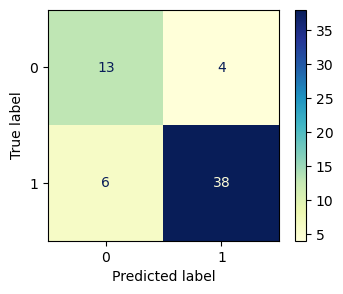

In [762]:
# from sklearn.metrics
conf_matrix = confusion_matrix(y_test_trim, y_pred)

fig, ax = plt.subplots(figsize=(4,3), dpi=100)

# from sklearn.metrics
display_confusion_matrix = ConfusionMatrixDisplay(conf_matrix, display_labels=clf.classes_)

display_confusion_matrix.plot(ax=ax, cmap='YlGnBu')

## CatBoostig

Модель сразу может работать на категориальных данных и делать небинарную классификацию. Но также требует заполненных пропущенных значений. 

Запустим её на трёх видах данных.
* Nan заполненные модой и мединой ```_imputed```
* Nan заполненные интеллектуальным способом, модой, мединой по категориям ```_fillna```
* ```_fillna_feat``` Feature Engineering - удаление шумовых признаков, уменьшение количества категорий

In [763]:
# _imputed
#
# Выделяем таргет и признаки
X_cat = train_imputed.drop(columns=['Onshore/Offshore'])
y_cat = train_imputed['Onshore/Offshore']

# Определяем список категориальных признаков (все, где тип данных object/str)
cat_features = X_cat.select_dtypes(include=[str, 'object']).columns.tolist()

# Делим на обучающую и тестовую выборки
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X_cat, y_cat, test_size=0.2, random_state=SEED)

# Создаем и обучаем модель
model_cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    verbose=100, # показывает прогресс каждые 100 итераций
    cat_features=cat_features, # самое важное для CatBoost
    auto_class_weights='SqrtBalanced', # 'Balanced' или 'SqrtBalanced'
)

model_cat.fit(X_train_cat, y_train_cat, eval_set=(X_test_cat, y_test_cat))

# Проверка результата
print(f"Accuracy: {model_cat.score(X_test_cat, y_test_cat)}")

y_pred_cat = model_cat.predict(X_test_cat)

print(f"Accuracy: {accuracy_score(y_test_cat, y_pred_cat):.4f}")
# {‘micro’, ‘macro’, ‘samples’, ‘weighted’, ‘binary’}
print(f"f1_score macro: {f1_score(y_test_cat, y_pred_cat, average = 'macro', zero_division=0):.4f}")
print(f"f1_score_weighted: {f1_score(y_test_cat, y_pred_cat, average = 'weighted', zero_division=0):.4f}")


0:	learn: 1.0510502	test: 1.0662954	best: 1.0662954 (0)	total: 8.95ms	remaining: 4.47s
100:	learn: 0.1669721	test: 0.5346307	best: 0.5292302 (76)	total: 759ms	remaining: 3s
200:	learn: 0.0747299	test: 0.5929976	best: 0.5292302 (76)	total: 1.5s	remaining: 2.23s
300:	learn: 0.0444680	test: 0.6320553	best: 0.5292302 (76)	total: 2.25s	remaining: 1.49s
400:	learn: 0.0303193	test: 0.6753959	best: 0.5292302 (76)	total: 2.99s	remaining: 739ms
499:	learn: 0.0230252	test: 0.7033525	best: 0.5292302 (76)	total: 3.75s	remaining: 0us

bestTest = 0.5292302407
bestIteration = 76

Shrink model to first 77 iterations.
Accuracy: 0.8548387096774194
Accuracy: 0.8548
f1_score macro: 0.5612
f1_score_weighted: 0.8493


In [764]:
# _fillna
#

# Выделяем таргет и признаки
X_cat = train_fillna.drop(columns=['Onshore/Offshore'])
y_cat = train_fillna['Onshore/Offshore']

# Определяем список категориальных признаков (все, где тип данных object/str)
cat_features = X_cat.select_dtypes(include=[str, 'object']).columns.tolist()

# Делим на обучающую и тестовую выборки
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X_cat, y_cat, test_size=0.2, random_state=SEED)

# Создаем и обучаем модель
model_cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    verbose=100, # показывает прогресс каждые 100 итераций
    cat_features=cat_features, # самое важное для CatBoost
    auto_class_weights='SqrtBalanced', # 'Balanced' или 'SqrtBalanced'
)

model_cat.fit(X_train_cat, y_train_cat, eval_set=(X_test_cat, y_test_cat))

# Проверка результата
print(f"Accuracy: {model_cat.score(X_test_cat, y_test_cat)}")

y_pred_cat = model_cat.predict(X_test_cat)

print(f"Accuracy: {accuracy_score(y_test_cat, y_pred_cat):.4f}")
# {‘micro’, ‘macro’, ‘samples’, ‘weighted’, ‘binary’}
print(f"f1_score macro: {f1_score(y_test_cat, y_pred_cat, average = 'macro', zero_division=0):.4f}")
print(f"f1_score_weighted: {f1_score(y_test_cat, y_pred_cat, average = 'weighted', zero_division=0):.4f}")


0:	learn: 1.0393607	test: 1.0495838	best: 1.0495838 (0)	total: 1.65ms	remaining: 825ms
100:	learn: 0.1635620	test: 0.6080902	best: 0.5627829 (53)	total: 733ms	remaining: 2.9s
200:	learn: 0.0732357	test: 0.6787591	best: 0.5627829 (53)	total: 1.51s	remaining: 2.24s
300:	learn: 0.0444032	test: 0.7287895	best: 0.5627829 (53)	total: 2.29s	remaining: 1.51s
400:	learn: 0.0303017	test: 0.7732435	best: 0.5627829 (53)	total: 3.06s	remaining: 756ms
499:	learn: 0.0229126	test: 0.7986121	best: 0.5627829 (53)	total: 3.88s	remaining: 0us

bestTest = 0.5627829076
bestIteration = 53

Shrink model to first 54 iterations.
Accuracy: 0.8870967741935484
Accuracy: 0.8871
f1_score macro: 0.5816
f1_score_weighted: 0.8781


Немного лучше.

In [765]:
# _fillna_feat
#

# Выделяем таргет и признаки
X_cat = train_fillna_feat.drop(columns=['Onshore/Offshore'])
y_cat = train_fillna_feat['Onshore/Offshore']

# Определяем список категориальных признаков (все, где тип данных object/str)
cat_features = X_cat.select_dtypes(include=[str, 'object']).columns.tolist()

# Делим на обучающую и тестовую выборки
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X_cat, y_cat, test_size=0.2, random_state=SEED)

# Создаем и обучаем модель
model_cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    verbose=100, # показывает прогресс каждые 100 итераций
    cat_features=cat_features, # самое важное для CatBoost
    auto_class_weights='SqrtBalanced', # 'Balanced' или 'SqrtBalanced'
)

model_cat.fit(X_train_cat, y_train_cat, eval_set=(X_test_cat, y_test_cat))

# Проверка результата
print(f"Accuracy: {model_cat.score(X_test_cat, y_test_cat)}")

y_pred_cat = model_cat.predict(X_test_cat)

print(f"Accuracy: {accuracy_score(y_test_cat, y_pred_cat):.4f}")
# {‘micro’, ‘macro’, ‘samples’, ‘weighted’, ‘binary’}
print(f"f1_score macro: {f1_score(y_test_cat, y_pred_cat, average = 'macro', zero_division=0):.4f}")
print(f"f1_score_weighted: {f1_score(y_test_cat, y_pred_cat, average = 'weighted', zero_division=0):.4f}")


0:	learn: 1.0257441	test: 1.0232524	best: 1.0232524 (0)	total: 982us	remaining: 490ms
100:	learn: 0.1610043	test: 0.5064994	best: 0.4935782 (51)	total: 597ms	remaining: 2.36s
200:	learn: 0.0719181	test: 0.5690066	best: 0.4935782 (51)	total: 1.27s	remaining: 1.9s
300:	learn: 0.0409529	test: 0.6055440	best: 0.4935782 (51)	total: 1.91s	remaining: 1.26s
400:	learn: 0.0285631	test: 0.6205624	best: 0.4935782 (51)	total: 2.52s	remaining: 623ms
499:	learn: 0.0217136	test: 0.6399534	best: 0.4935782 (51)	total: 3.14s	remaining: 0us

bestTest = 0.4935782343
bestIteration = 51

Shrink model to first 52 iterations.
Accuracy: 0.9193548387096774
Accuracy: 0.9194
f1_score macro: 0.6120
f1_score_weighted: 0.9125


Самый лучший результат на обработанных данных. При этом зависит от параметра SEED $\pm$ 0.02.

confusion matrix

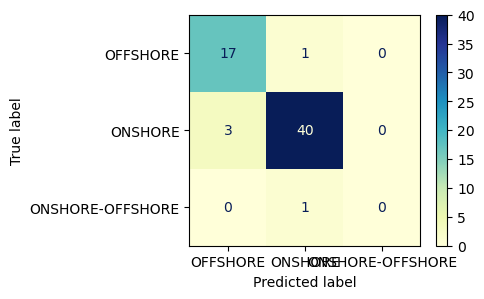

In [766]:
# from sklearn.metrics
conf_matrix = confusion_matrix(y_test_cat, y_pred_cat)

fig, ax = plt.subplots(figsize=(4,3), dpi=100)

# from sklearn.metrics
display_confusion_matrix = ConfusionMatrixDisplay(conf_matrix, display_labels=model_cat.classes_)

display_confusion_matrix.plot(ax=ax, cmap='YlGnBu')

Миноритарный клас ни разу не предсказан.

# Финальный сабмит

In [767]:
display(train.shape)
display(test.shape)
train = train.dropna()
display(train.shape)

(309, 143)

(133, 142)

(309, 143)

In [768]:
display(X.shape)
display(y.shape)
display(X_trim.shape)
display(y_trim.shape)

(309, 142)

(309,)

(304, 142)

(304,)

In [769]:
# заполним числовые NaN медианными значениями (pandas расчитает это самостоятельно)
# оставшиеся строковые, как Unknown
test = test.fillna(test.median())
test = test.fillna('Unknown')

## CatBoosting _feat

По предварительным проверкам лучший результат показала модель CatBoosting на подготовленных данных ```_fillna_feat```.

In [770]:
# Выделяем таргет и признаки
X_cat = train_fillna_feat.drop(columns=['Onshore/Offshore'])
y_cat = train_fillna_feat['Onshore/Offshore']

# Подготовленные признаки для теста (из которых будем делать прогноз)
X_cat_test = test_fillna_feat 

# Заполняем пропуски в категориальных колонках строкой 'None'
X_cat[cat_features] = X_cat[cat_features].fillna('None').astype(str)
X_cat_test[cat_features] = test_fillna_feat[cat_features].fillna('None').astype(str)

# Определяем список категориальных признаков (все, где тип данных object/str)
cat_features = X_cat.select_dtypes(include=[str, 'object']).columns.tolist()

# Создаем и обучаем модель
model_cat = CatBoostClassifier(
    iterations=73,
    learning_rate=0.1,
    depth=6,
    verbose=23, # показывает прогресс каждые ... итераций
    cat_features=cat_features, # самое важное для CatBoost
    auto_class_weights='SqrtBalanced', # 'Balanced' или 'SqrtBalanced'
)

model_cat.fit(X_cat, y_cat)

y_pred_cat = model_cat.predict(X_cat_test)

# Превращаем двумерный массив строк в одномерный массив чисел
y_pred_cat = np.array([label_mapping[x[0]] for x in y_pred_cat])

y_pred_cat

0:	learn: 1.0257355	total: 1.91ms	remaining: 138ms
23:	learn: 0.4736344	total: 67.4ms	remaining: 138ms
46:	learn: 0.3201034	total: 140ms	remaining: 77.6ms
69:	learn: 0.2375650	total: 214ms	remaining: 9.18ms
72:	learn: 0.2293752	total: 225ms	remaining: 0us


array([1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1])

In [771]:
submition_EDA_FE_CatBoost_90741 = np.array(
      [1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1])

In [772]:
submition_EDA_FE_CatBoost_88848 = np.array(
      [1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1])

In [773]:
# проверка равенства, что текущее предсказание последнему сабмиту
all(y_pred_cat == submition_EDA_FE_CatBoost_88848)

True

In [774]:
# выгрузка в файл для сабмита
ans_cat = pd.DataFrame(y_pred_cat, columns=['Onshore/Offshore'])
ans_cat.reset_index(inplace=True)
ans_cat.to_csv('./classification-of-oil-and-gas/submition_EDA_FE_CatBoost.csv', index=False)

Результат на Кагле $0.88848$.

!![kaggle submit](Oil_and_Gas_Field_Development_DZ_3_Kaggle_submit.png)

## Предыдущие сабмиты

Оставляю предыдущие финальные сабмиты, на случай если этот результат надо будет воспроизвести.

### Random Forest Trim _balanced

In [775]:
# Создание и обучение модели
clf_best = RandomForestClassifier(
    n_estimators=100, criterion='gini', random_state=SEED,
    n_jobs=-1, # использовать все ядра
    max_features='log2',
    class_weight='balanced',
)
clf_best.fit(X_trim, y_trim)

# Предсказание и оценка качества модели
y_pred_clf = clf_best.predict(test)
y_pred_clf

array([1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1])

In [776]:
submition_EDA_FE_dummies_Trim_RF_balanced_100_log2_89653 = np.array(
      [1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1])

In [777]:
submition_EDA_FE_dummies_Trim_RF_balanced_100_log2_86261 = np.array(
      [1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1])

In [778]:
# проверка равенства, что текущее предсказание последнему сабмиту
all(y_pred_clf == submition_EDA_FE_dummies_Trim_RF_balanced_100_log2_86261)

True

In [779]:
# выгрузка в файл для сабмита
ans_clf = pd.DataFrame(y_pred_clf, columns=['Onshore/Offshore'])
ans_clf.reset_index(inplace=True)
ans_clf.to_csv('./classification-of-oil-and-gas/submition_EDA_FE_dummies_Trim_RF_balanced-100-log2.csv', index=False)

### Decision Tree baseline Trim
 

In [780]:
# создадим модель
baseline_tree = DecisionTreeClassifier(random_state=SEED)

# обучение модели
baseline_tree.fit(X_trim, y_trim)

# предсказание ответов для тестовой выборки
y_pred_baseline_tree = baseline_tree.predict(test)
y_pred_baseline_tree

array([1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1])

In [781]:
submition_EDA_FE_wo_BN_dummies_Orig_DTC_baseline_88652 = np.array(
      [1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 2, 0, 0, 1, 0, 0, 1, 1, 1, 1, 2, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 2, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1])

In [782]:
submition_EDA_FE_dummies_Orig_DTC_baseline_88652 = np.array(
      [1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 2, 0, 0, 1, 0, 0, 1, 1, 1, 1, 2, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 2, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1])

In [783]:
# проверка равенства, что текущее предсказание последнему сабмиту
all(y_pred_baseline_tree == submition_EDA_FE_wo_BN_dummies_Orig_DTC_baseline_88652)

False

In [784]:
# проверка равенства, что текущее предсказание последнему сабмиту
all(y_pred_baseline_tree == submition_EDA_FE_dummies_Orig_DTC_baseline_88652)

False

In [785]:
submition_EDA_FE_dummies_Trim_DTC_baseline_83366 = np.array(
      [1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 2, 0, 0, 1, 0, 0, 1, 1, 1, 1, 2, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 2, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1])

In [786]:
# проверка равенства, что текущее предсказание последнему сабмиту
all(y_pred_baseline_tree == submition_EDA_FE_dummies_Trim_DTC_baseline_83366)

False

In [787]:
SEED

42

In [788]:
# выгрузка в файл для сабмита
ans_clf = pd.DataFrame(y_pred_baseline_tree, columns=['Onshore/Offshore'])
ans_clf.reset_index(inplace=True)
ans_clf.to_csv('./classification-of-oil-and-gas/submition_EDA_FE_dummies_Trim_DTC_baseline.csv', index=False)

### Random Forest

In [789]:
# Создание и обучение модели
clf_best = RandomForestClassifier(
    n_estimators=100, criterion='gini', random_state=SEED,
    n_jobs=-1, # использовать все ядра
    max_features='log2',
    #max_depth=5,
    #min_samples_leaf=7,
)
clf_best.fit(X, y)

# Предсказание и оценка качества модели
y_pred_clf = clf_best.predict(test)
y_pred_clf

array([1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 2, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1])

In [790]:
submition_EDA_FE_dummies_Orig_RF_100_log2_86432 = np.array(
      [1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1])

In [791]:
# проверка равенства, что текущее предсказание последнему сабмиту
all(y_pred_clf == submition_EDA_FE_dummies_Orig_RF_100_log2_86432)

False

In [792]:
# выгрузка в файл для сабмита
ans_clf = pd.DataFrame(y_pred_clf, columns=['Onshore/Offshore'])
ans_clf.reset_index(inplace=True)
ans_clf.to_csv('./classification-of-oil-and-gas/submition_EDA_FE_dummies_Orig_RF-100-log2.csv', index=False)

### baseline Decision Tree

In [793]:
# создадим модель
baseline_tree = DecisionTreeClassifier(random_state=SEED)

# обучение модели
baseline_tree.fit(X, y)

# предсказание ответов для тестовой выборки
y_pred_baseline_tree = baseline_tree.predict(test)
y_pred_baseline_tree

array([1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 2, 0, 0, 1, 0, 0, 1, 1, 1, 1, 2, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 2, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 2, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1])

In [794]:
submition_EDA_FE_wo_BN_dummies_Orig_DTC_baseline_88652 = np.array(
      [1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 2, 0, 0, 1, 0, 0, 1, 1, 1, 1, 2, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 2, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1])

In [795]:
submition_EDA_FE_dummies_Orig_DTC_baseline_88652 = np.array(
      [1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 2, 0, 0, 1, 0, 0, 1, 1, 1, 1, 2, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 2, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1])

In [796]:
# проверка равенства, что текущее предсказание последнему сабмиту
all(y_pred_baseline_tree == submition_EDA_FE_wo_BN_dummies_Orig_DTC_baseline_88652)

False

In [797]:
# проверка равенства, что текущее предсказание последнему сабмиту
all(y_pred_baseline_tree == submition_EDA_FE_dummies_Orig_DTC_baseline_88652)

False

In [798]:
# выгрузка в файл для сабмита
ans_clf = pd.DataFrame(y_pred_baseline_tree, columns=['Onshore/Offshore'])
ans_clf.reset_index(inplace=True)
ans_clf.to_csv('./classification-of-oil-and-gas/submition_EDA_FE_dummies_Orig_DCT_baseline.csv', index=False)

### X_trim ADASYN_n5 DTC_d7_l5

In [799]:

# Применяем ADASYN
X_trim_all_ADASYN_n5, y_trim_all_ADASYN_n5 = adasyn_n5.fit_resample(X_trim, y_trim)

# Создадим модель дерева решений
tree = DecisionTreeClassifier(
    random_state=SEED, 
    max_depth=7, 
    min_samples_leaf=5,
)

# обучение модели
tree.fit(X_trim_all_ADASYN_n5, y_trim_all_ADASYN_n5)

# предсказание ответов для тестовой выборки
y_pred_tree_adasyn_n5 = tree.predict(test)

y_pred_tree_adasyn_n5

array([1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1])

In [800]:
submition_ADASYN_DCT_d7_l5_85396 = np.array(
      [1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 2,
       1, 1, 1, 0, 0, 1, 0, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 2, 2, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       2, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1])

In [801]:
# проверка, равены текущее предсказание последнему сабмиту
all(y_pred_tree_adasyn_n5 == submition_ADASYN_DCT_d7_l5_85396)

False

In [802]:
submition_Trim_ADASYN_n5_DCT_d7_l5_84795 = np.array(
      [1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1])

In [803]:
# проверка, равены текущее предсказание последнему сабмиту
all(y_pred_tree_adasyn_n5 == submition_Trim_ADASYN_n5_DCT_d7_l5_84795)

True

In [804]:
# выгрузка в файл для сабмита
ans_df = pd.DataFrame(y_pred_tree_adasyn_n5, columns=['Onshore/Offshore'])
ans_df.reset_index(inplace=True)
ans_df.to_csv('./classification-of-oil-and-gas/submition_EDA_FE_dummies_Trim_ADASYN-n5_DTC-d7-l5.csv', index=False)

### предыдущие

In [805]:

# Применяем ADASYN
X_all_ADASYN, y_all_ADASYN = adasyn.fit_resample(X, y)

# Создадим модель дерева решений
tree = DecisionTreeClassifier(
    random_state=SEED, 
    max_depth=best_max_depth, 
    min_samples_leaf=best_min_samples_leaf,
)

# обучение модели
tree.fit(X_all_ADASYN, y_all_ADASYN)

# предсказание ответов для тестовой выборки
y_pred_tree = tree.predict(test)

y_pred_tree

array([1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 2,
       1, 1, 1, 0, 0, 1, 0, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 2, 2, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       2, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1])

In [806]:
submition_ADASYN_DCT_d7_l5_85396 = np.array(
      [1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 2,
       1, 1, 1, 0, 0, 1, 0, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 2, 2, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       2, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1])

In [807]:
# проверка, равены текущее предсказание последнему сабмиту
all(y_pred_tree == submition_ADASYN_DCT_d7_l5_85396)

True

In [808]:
# выгрузка в файл для сабмита
ans_df = pd.DataFrame(y_pred_tree, columns=['Onshore/Offshore'])
ans_df.reset_index(inplace=True)
ans_df.to_csv('./classification-of-oil-and-gas/submition_EDA_FE_dummies_ADASYN_DTC-d7-l5.csv', index=False)

In [809]:
submition_ADASYN_DCT_d7_l5_83786 = np.array(
      [0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 2, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 2, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1])

In [810]:
submition_ADASYN_DCT_86676 = np.array(
      [1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 2, 0, 0, 1, 0, 0, 1, 1, 1, 2, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 2, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1])

In [811]:
submition_baseline_DCT_fillna_map_group_log_88652 = np.array(
      [1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 2, 0, 0, 1, 0, 0, 1, 1, 1, 1, 2, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 2, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1])

# Вывод по проделанной работе

Самый лучший результат на тестовой выборке показала модель CatBoosting, при этом она сразу работает и с категориальными данными и делает небинарную классификацию. С другой стороны модели RandomForeset на обрезанной выборке и с балансировкой классов, показывает схожий результат ненамного устпая, а на f1_macro даже превосходит.

При этом все модели колеблются по скору на Кагле около $0.88$. А так же чувствительны к параметру ```random_state```. Похоже, что для дальнейшего улучшения результат требуется дополнительная работа над признаками. Оценка влияния на целевую переменную и последущее их сокращение. Так как их очень много $142$ и модель сильно зависит от них.

С другой стороны, даже при таком количестве признаков, модели показывают большее качество, чем простое угадывание.

In [812]:
test.shape

(133, 142)